<a href="https://colab.research.google.com/github/AndreaAramburo93/Analitica/blob/main/Analisis%20de%20covid%2019%20Colombia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Andrea Aramburo Pelaez

*   Actividad 1


*   1152202723
*   Ingenieria de software y datos
*   Analitica de datos
*   2026


# Entrega 1



Importar librerias


## Ejercicio 1

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [129]:
# Instalar una biblioteca de Python (ejemplo: requests)
!pip install requests

Importe inicial de datos y conexion con Drive

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define the correct column names based on the dataset's expected structure
# Added 'Extra_Column' to match the 23 fields found in line 2, as indicated by the ParserError.
column_names = [
    'fecha reporte web', 'ID de caso', 'Fecha de notificación',
    'Código DIVIPOLA departamento', 'Nombre departamento',
    'Código DIVIPOLA municipio', 'Nombre municipio', 'Edad',
    'Unidad de medida de edad', 'Sexo', 'Tipo de contagio',
    'Ubicación del caso', 'Estado', 'Código ISO del país',
    'Nombre del país', 'Pertenencia étnica', 'Nombre del grupo étnico',
    'Tipo de recuperación', 'Fecha de inicio de síntomas',
    'Fecha de diagnóstico', 'Fecha de muerte', 'Fecha de recuperación',
    'Extra_Column' # Added this to match the 'saw 23' fields
]

# Read the CSV with no header and assign the custom column names
df = pd.read_csv('/content/Casos.csv', header=None, names=column_names)

# Ver las primeras filas para confirmar que cargó bien
print(df.head())

# Info general del dataset (columnas, tipos de dato, nulos)
print(df.info())

# Dimensiones (filas, columnas)
print(df.shape)

/tmp/ipykernel_632/2789005128.py:21: DtypeWarning: Columns (7,8,13,14,21) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/Casos.csv', header=None, names=column_names)


     fecha reporte web  ID de caso  Fecha de notificación  \
0    fecha reporte web  ID de caso  Fecha de notificación   
1  2020-12-24 00:00:00   1,556,979    2020-12-22 00:00:00   
2  2020-12-24 00:00:00   1,556,980    2020-12-19 00:00:00   
3  2020-12-24 00:00:00   1,556,981    2020-12-19 00:00:00   
4  2020-12-24 00:00:00   1,556,982    2020-12-22 00:00:00   

   Código DIVIPOLA departamento  Nombre departamento  \
0  Código DIVIPOLA departamento  Nombre departamento   
1                            76                VALLE   
2                            76                VALLE   
3                            76                VALLE   
4                            76                VALLE   

   Código DIVIPOLA municipio  Nombre municipio  Edad  \
0  Código DIVIPOLA municipio  Nombre municipio  Edad   
1                     76,001              CALI    67   
2                     76,001              CALI    66   
3                     76,001              CALI    68   
4               

In [131]:
# Eliminar la primera fila (índice 0) que contiene los encabezados duplicados
df = df.drop(df.index[0])

# Convertir 'Edad' y 'Unidad de medida de edad' a numérico
# Usamos errors='coerce' para convertir los valores no numéricos a NaN
df['Edad'] = pd.to_numeric(df['Edad'], errors='coerce')
df['Unidad de medida de edad'] = pd.to_numeric(df['Unidad de medida de edad'], errors='coerce')

print("DataFrame después de eliminar la fila de encabezado duplicada y convertir 'Edad' a numérico:")
display(df.head())
df.info()

DataFrame después de eliminar la fila de encabezado duplicada y convertir 'Edad' a numérico:


,fecha reporte web,ID de caso,Fecha de notificación,Código DIVIPOLA departamento,Nombre departamento,Código DIVIPOLA municipio,Nombre municipio,Edad,Unidad de medida de edad,Sexo,...,Código ISO del país,Nombre del país,Pertenencia étnica,Nombre del grupo étnico,Tipo de recuperación,Fecha de inicio de síntomas,Fecha de diagnóstico,Fecha de muerte,Fecha de recuperación,Extra_Column
1,2020-12-24 00:00:00,"1,556,979",2020-12-22 00:00:00,76,VALLE,"76,001",CALI,67,1,F,...,NaN,NaN,Recuperado,2020-12-21 00:00:00,NaN,2020-12-23 00:00:00,2021-01-04 00:00:00,Tiempo,6,NaN
2,2020-12-24 00:00:00,"1,556,980",2020-12-19 00:00:00,76,VALLE,"76,001",CALI,66,1,F,...,NaN,NaN,Recuperado,2020-12-07 00:00:00,NaN,2020-12-23 00:00:00,2020-12-25 00:00:00,Tiempo,6,NaN
3,2020-12-24 00:00:00,"1,556,981",2020-12-19 00:00:00,76,VALLE,"76,001",CALI,68,1,F,...,NaN,NaN,Recuperado,2020-12-18 00:00:00,NaN,2020-12-22 00:00:00,2021-01-01 00:00:00,Tiempo,6,NaN
4,2020-12-24 00:00:00,"1,556,982",2020-12-22 00:00:00,76,VALLE,"76,001",CALI,74,1,F,...,NaN,NaN,Fallecido,2020-12-17 00:00:00,2020-12-30 00:00:00,2020-12-23 00:00:00,NaN,NaN,6,NaN
5,2020-12-24 00:00:00,"1,556,983",2020-12-22 00:00:00,76,VALLE,"76,001",CALI,65,1,F,...,NaN,NaN,Recuperado,2020-12-21 00:00:00,NaN,2020-12-23 00:00:00,2021-01-04 00:00:00,Tiempo,6,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 749694 entries, 1 to 749694
Data columns (total 23 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   fecha reporte web             749694 non-null  object
 1   ID de caso                    749694 non-null  object
 2   Fecha de notificación         749694 non-null  object
 3   Código DIVIPOLA departamento  749694 non-null  object
 4   Nombre departamento           749694 non-null  object
 5   Código DIVIPOLA municipio     749694 non-null  object
 6   Nombre municipio              749694 non-null  object
 7   Edad                          749694 non-null  int64 
 8   Unidad de medida de edad      749694 non-null  int64 
 9   Sexo                          749694 non-null  object
 10  Tipo de contagio              749694 non-null  object
 11  Ubicación del caso            746468 non-null  object
 12  Estado                        746468 non-null  object
 13 

### Re-identificación de variables numéricas y categóricas

Ahora que las columnas 'Edad' y 'Unidad de medida de edad' han sido convertidas a tipos numéricos, es necesario re-ejecutar la identificación de variables numéricas y categóricas para que la lista `numericas` contenga los nombres de estas columnas.

In [132]:
# Analisis de tipo de variables actualizado
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categoricas = df.select_dtypes(include=['object']).columns.tolist()

print(f"Variables numéricas ({len(numericas)}): {numericas}")
print(f"Variables categóricas ({len(categoricas)}): {categoricas}")

Variables numéricas (2): ['Edad', 'Unidad de medida de edad']
Variables categóricas (21): ['fecha reporte web', 'ID de caso', 'Fecha de notificación', 'Código DIVIPOLA departamento', 'Nombre departamento', 'Código DIVIPOLA municipio', 'Nombre municipio', 'Sexo', 'Tipo de contagio', 'Ubicación del caso', 'Estado', 'Código ISO del país', 'Nombre del país', 'Pertenencia étnica', 'Nombre del grupo étnico', 'Tipo de recuperación', 'Fecha de inicio de síntomas', 'Fecha de diagnóstico', 'Fecha de muerte', 'Fecha de recuperación', 'Extra_Column']


### Análisis descriptivo para variables numéricas del dataset (corregido)

Ahora que la columna 'Edad' es numérica, podemos aplicar el método `describe().T` para obtener un resumen estadístico.

In [133]:
df[numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
Edad,749694.0,39.635665,17.730217,1.0,27.0,38.0,52.0,108.0
Unidad de medida de edad,749694.0,1.003345,0.062576,1.0,1.0,1.0,1.0,3.0


Obtén la información estructural del DataFrame

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 749694 entries, 1 to 749694
Data columns (total 23 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   fecha reporte web             749694 non-null  object
 1   ID de caso                    749694 non-null  object
 2   Fecha de notificación         749694 non-null  object
 3   Código DIVIPOLA departamento  749694 non-null  object
 4   Nombre departamento           749694 non-null  object
 5   Código DIVIPOLA municipio     749694 non-null  object
 6   Nombre municipio              749694 non-null  object
 7   Edad                          749694 non-null  int64 
 8   Unidad de medida de edad      749694 non-null  int64 
 9   Sexo                          749694 non-null  object
 10  Tipo de contagio              749694 non-null  object
 11  Ubicación del caso            746468 non-null  object
 12  Estado                        746468 non-null  object
 13 

Visualiza la estructura del DataFrame (.head(),.tail() y .sample()) (10 puntos).

In [135]:
# Primeras filas
df.head()

,fecha reporte web,ID de caso,Fecha de notificación,Código DIVIPOLA departamento,Nombre departamento,Código DIVIPOLA municipio,Nombre municipio,Edad,Unidad de medida de edad,Sexo,...,Código ISO del país,Nombre del país,Pertenencia étnica,Nombre del grupo étnico,Tipo de recuperación,Fecha de inicio de síntomas,Fecha de diagnóstico,Fecha de muerte,Fecha de recuperación,Extra_Column
1,2020-12-24 00:00:00,"1,556,979",2020-12-22 00:00:00,76,VALLE,"76,001",CALI,67,1,F,...,NaN,NaN,Recuperado,2020-12-21 00:00:00,NaN,2020-12-23 00:00:00,2021-01-04 00:00:00,Tiempo,6,NaN
2,2020-12-24 00:00:00,"1,556,980",2020-12-19 00:00:00,76,VALLE,"76,001",CALI,66,1,F,...,NaN,NaN,Recuperado,2020-12-07 00:00:00,NaN,2020-12-23 00:00:00,2020-12-25 00:00:00,Tiempo,6,NaN
3,2020-12-24 00:00:00,"1,556,981",2020-12-19 00:00:00,76,VALLE,"76,001",CALI,68,1,F,...,NaN,NaN,Recuperado,2020-12-18 00:00:00,NaN,2020-12-22 00:00:00,2021-01-01 00:00:00,Tiempo,6,NaN
4,2020-12-24 00:00:00,"1,556,982",2020-12-22 00:00:00,76,VALLE,"76,001",CALI,74,1,F,...,NaN,NaN,Fallecido,2020-12-17 00:00:00,2020-12-30 00:00:00,2020-12-23 00:00:00,NaN,NaN,6,NaN
5,2020-12-24 00:00:00,"1,556,983",2020-12-22 00:00:00,76,VALLE,"76,001",CALI,65,1,F,...,NaN,NaN,Recuperado,2020-12-21 00:00:00,NaN,2020-12-23 00:00:00,2021-01-04 00:00:00,Tiempo,6,NaN


In [136]:
# Últimas filas
df.tail()

,fecha reporte web,ID de caso,Fecha de notificación,Código DIVIPOLA departamento,Nombre departamento,Código DIVIPOLA municipio,Nombre municipio,Edad,Unidad de medida de edad,Sexo,...,Código ISO del país,Nombre del país,Pertenencia étnica,Nombre del grupo étnico,Tipo de recuperación,Fecha de inicio de síntomas,Fecha de diagnóstico,Fecha de muerte,Fecha de recuperación,Extra_Column
749690,2021-07-17 00:00:00,"4,608,691",2021-07-14 00:00:00,5,ANTIOQUIA,"5,847",URRAO,71,1,F,...,NaN,NaN,Recuperado,2021-07-11 00:00:00,NaN,2021-07-15 00:00:00,2021-07-27 00:00:00,Tiempo,6.0,NaN
749691,2021-06-04 00:00:00,"3,514,862",2021-05-26 00:00:00,11,BOGOTA,"11,001",BOGOTA,12,1,F,...,NaN,NaN,Recuperado,2021-05-25 00:00:00,NaN,2021-06-01 00:00:00,2021-06-08 00:00:00,Tiempo,6.0,NaN
749692,2021-06-04 00:00:00,"3,514,863",2021-05-24 00:00:00,11,BOGOTA,"11,001",BOGOTA,12,1,F,...,NaN,NaN,Recuperado,2021-05-20 00:00:00,NaN,2021-06-02 00:00:00,2021-06-05 00:00:00,PCR,6.0,NaN
749693,2021-06-04 00:00:00,"3,514,864",2021-05-27 00:00:00,11,BOGOTA,"11,001",BOGOTA,13,1,F,...,NaN,NaN,Recuperado,2021-05-23 00:00:00,NaN,2021-06-01 00:00:00,2021-06-10 00:00:00,Tiempo,6.0,NaN
749694,2021-06-04 00:00:00,"3,514,865",2021-05-27 00:00:00,11,BOGOTA,"11,001",BOGOTA,13,1,M,...,NaN,NaN,Recuperado,2021-05-19 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN


In [137]:
# Muestra aleatoria
df.sample(5)

,fecha reporte web,ID de caso,Fecha de notificación,Código DIVIPOLA departamento,Nombre departamento,Código DIVIPOLA municipio,Nombre municipio,Edad,Unidad de medida de edad,Sexo,...,Código ISO del país,Nombre del país,Pertenencia étnica,Nombre del grupo étnico,Tipo de recuperación,Fecha de inicio de síntomas,Fecha de diagnóstico,Fecha de muerte,Fecha de recuperación,Extra_Column
220590,2021-01-04 00:00:00,"1,679,235",2021-01-01 00:00:00,11,BOGOTA,"11,001",BOGOTA,28,1,M,...,NaN,NaN,Recuperado,2020-12-28 00:00:00,NaN,2021-01-02 00:00:00,2021-01-14 00:00:00,Tiempo,6,NaN
533553,2021-05-29 00:00:00,"3,349,765",2021-05-25 00:00:00,76,VALLE,"76,001",CALI,65,1,F,...,NaN,NaN,Recuperado,2021-05-25 00:00:00,NaN,2021-05-27 00:00:00,2021-06-08 00:00:00,Tiempo,6,NaN
17464,2020-07-09 00:00:00,"133,938",2020-06-28 00:00:00,11,BOGOTA,"11,001",BOGOTA,21,1,M,...,NaN,NaN,Recuperado,NaN,NaN,2020-07-09 00:00:00,2021-04-07 00:00:00,PCR,6,NaN
564832,2021-06-05 00:00:00,"3,523,999",2021-05-24 00:00:00,50,META,"50,001",VILLAVICENCIO,58,1,F,...,NaN,NaN,Fallecido,2021-05-17 00:00:00,2021-06-09 00:00:00,2021-06-04 00:00:00,NaN,NaN,6,NaN
420997,2021-06-01 00:00:00,"3,425,005",2021-05-27 00:00:00,5,ANTIOQUIA,"5,837",TURBO,32,1,M,...,NaN,NaN,Recuperado,2021-05-25 00:00:00,NaN,2021-05-29 00:00:00,2021-06-08 00:00:00,Tiempo,6,NaN


Visualizar variables

In [138]:
variables = ['Estado', 'Ubicación del caso', 'Sexo', 'Tipo de contagio', 'Nombre del país',
             'Tipo de recuperación', 'Pertenencia étnica', 'Nombre del grupo étnico']

for col in variables:
    print(f"\n{'='*50}")
    print(f"Variable: {col}")
    print('='*50)
    print(df[col].value_counts(dropna=False))


Variable: Estado
Estado
Leve         726303
Fallecido     19938
NaN            3226
leve            227
Name: count, dtype: int64

Variable: Ubicación del caso
Ubicación del caso
Casa         725745
Fallecido     19938
NaN            3226
casa            780
CASA              5
Name: count, dtype: int64

Variable: Sexo
Sexo
F    393612
M    356081
f         1
Name: count, dtype: int64

Variable: Tipo de contagio
Tipo de contagio
Comunitaria    486778
Relacionado    262674
Importado         242
Name: count, dtype: int64

Variable: Nombre del país
Nombre del país
NaN                                     749451
ESTADOS UNIDOS DE AMÉRICA                   93
MÉXICO                                      33
BRASIL                                      16
ESPAÑA                                      16
PANAMÁ                                      12
VENEZUELA                                   12
REPÚBLICA DOMINICANA                        10
ECUADOR                                      7
CHILE   

Limpieza y estandarizacion del data set

In [139]:
# Estandariza los nombres de columna
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['fecha reporte web', 'ID de caso', 'Fecha de notificación', 'Código DIVIPOLA departamento', 'Nombre departamento', 'Código DIVIPOLA municipio', 'Nombre municipio', 'Edad', 'Unidad de medida de edad', 'Sexo', 'Tipo de contagio', 'Ubicación del caso', 'Estado', 'Código ISO del país', 'Nombre del país', 'Pertenencia étnica', 'Nombre del grupo étnico', 'Tipo de recuperación', 'Fecha de inicio de síntomas', 'Fecha de diagnóstico', 'Fecha de muerte', 'Fecha de recuperación', 'Extra_Column']


In [140]:
#vamos a eliminar duplicados con el dro
print(f"Duplicados antes: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Duplicados después: {df.duplicated().sum()}")

Duplicados antes: 0
Duplicados después: 0


In [141]:
#estandarizacion de nombres de columnas, clave para identificar variables
categoricas = df.select_dtypes(include=['object']).columns.tolist()

for col in categoricas:
    df[col] = df[col].astype(str).str.strip()  # quita espacios al inicio/final
    df[col] = df[col].replace('nan', np.nan)   # restaura los NaN reales (str() los convierte en texto 'nan')

In [142]:
#estandarizacion de nombres con mayuscular
columnas_a_normalizar = ['Sexo', 'Estado', 'Tipo de contagio', 'Tipo de recuperación']

for col in columnas_a_normalizar:
    if col in df.columns:
        df[col] = df[col].str.title()  # "masculino" -> "Masculino"

In [143]:
#revisemos tipo de dato para unificar y corregir los que tienen un tipo de dato erroneo, esto permite generar asocacion de variabkes
df.dtypes

,0
fecha reporte web,object
ID de caso,object
Fecha de notificación,object
Código DIVIPOLA departamento,object
Nombre departamento,object
Código DIVIPOLA municipio,object
Nombre municipio,object
Edad,int64
Unidad de medida de edad,int64
Sexo,object


In [144]:
# Valores nulos
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df)) * 100
resumen_nulos = pd.DataFrame({'nulos': nulos, '% nulos': porcentaje_nulos})
print(resumen_nulos[resumen_nulos['nulos'] > 0].sort_values('% nulos', ascending=False))

# Duplicados
print(f"\nFilas duplicadas: {df.duplicated().sum()}")

# Valores únicos por columna (útil para detectar categóricas)
print("\nValores únicos por columna:")
print(df.nunique())

                              nulos    % nulos
Nombre del país              749451  99.967587
Código ISO del país          749451  99.967587
Extra_Column                 739785  98.678261
Tipo de recuperación         726530  96.910206
Nombre del grupo étnico       77003  10.271257
Fecha de diagnóstico          22593   3.013630
Fecha de muerte               22593   3.013630
Estado                         3226   0.430309
Ubicación del caso             3226   0.430309
Pertenencia étnica             2654   0.354011
Fecha de inicio de síntomas     272   0.036281
Fecha de recuperación             1   0.000133

Filas duplicadas: 0

Valores únicos por columna:
fecha reporte web                  418
ID de caso                      749694
Fecha de notificación              538
Código DIVIPOLA departamento        36
Nombre departamento                 37
Código DIVIPOLA municipio         1108
Nombre municipio                  1030
Edad                               108
Unidad de medida de edad   

Como no tenemos variables tipo texto, podemos reconcoer que estan en una buena categoria. Esto era solo parte del analisis exploratorio inicial

In [145]:
#busqueda de nombre de variables y datos, esto ayuda a identificar los datos y saber si debemos unificar alguno

for col in variables:
    if col in df.columns:
        print(f"\n{col}:")
        print(df[col].unique())


Estado:
['Leve' 'Fallecido' nan]

Ubicación del caso:
['Casa' 'Fallecido' nan 'casa' 'CASA']

Sexo:
['F' 'M']

Tipo de contagio:
['Comunitaria' 'Relacionado' 'Importado']

Nombre del país:
[nan 'MÉXICO' 'REPÚBLICA DOMINICANA' 'ALEMANIA' 'FRANCIA'
 'ESTADOS UNIDOS DE AMÉRICA' 'ECUADOR' 'PORTUGAL' 'BRASIL' 'EL SALVADOR'
 'PANAMÁ' 'EMIRATOS ARABES UNIDOS' 'ARMENIA' 'DOMINICA' 'NORUEGA' 'PERÚ'
 'ESPAÑA' 'INDONESIA' 'VENEZUELA' 'CHILE' 'TRINIDAD Y TOBAGO' 'NICARAGUA'
 'PERU' 'ISLAS VÍRGENES DE LOS ESTADOS UNIDOS' 'ARGENTINA' 'ITALIA'
 'CURAZAO' 'PUERTO RICO' 'EGIPTO' 'FEDERACIÓN DE RUSIA' 'CANADÁ'
 'GUATEMALA']

Tipo de recuperación:
[nan '2020-12-30 00:00:00' '2020-12-26 00:00:00' '2020-11-11 00:00:00'
 '2020-11-12 00:00:00' '2020-11-16 00:00:00' '2020-12-23 00:00:00'
 '2021-01-09 00:00:00' '2020-08-10 00:00:00' '2020-07-24 00:00:00'
 '2020-07-29 00:00:00' '2020-08-07 00:00:00' '2020-08-08 00:00:00'
 '2021-01-24 00:00:00' '2020-07-23 00:00:00' '2022-02-27 00:00:00'
 '2020-08-01 00:00:00' 

In [146]:
print("="*50)
print("RESUMEN POST-LIMPIEZA")
print("="*50)
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
print(f"Duplicados: {df.duplicated().sum()}")
print(f"Total nulos: {df.isnull().sum().sum()}")
df.info()

RESUMEN POST-LIMPIEZA
Filas: 749694 | Columnas: 23
Duplicados: 0
Total nulos: 3096785
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 749694 entries, 1 to 749694
Data columns (total 23 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   fecha reporte web             749694 non-null  object
 1   ID de caso                    749694 non-null  object
 2   Fecha de notificación         749694 non-null  object
 3   Código DIVIPOLA departamento  749694 non-null  object
 4   Nombre departamento           749694 non-null  object
 5   Código DIVIPOLA municipio     749694 non-null  object
 6   Nombre municipio              749694 non-null  object
 7   Edad                          749694 non-null  int64 
 8   Unidad de medida de edad      749694 non-null  int64 
 9   Sexo                          749694 non-null  object
 10  Tipo de contagio              749694 non-null  object
 11  Ubicación del caso            7


## Ejercicio 2
Analisis Descriptivo


Realizar analisis descriptivo

In [147]:
#Analisis de tipo de variables
numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categoricas = df.select_dtypes(include=['object']).columns.tolist()

print(f"Variables numéricas ({len(numericas)}): {numericas}")
print(f"Variables categóricas ({len(categoricas)}): {categoricas}")

Variables numéricas (2): ['Edad', 'Unidad de medida de edad']
Variables categóricas (21): ['fecha reporte web', 'ID de caso', 'Fecha de notificación', 'Código DIVIPOLA departamento', 'Nombre departamento', 'Código DIVIPOLA municipio', 'Nombre municipio', 'Sexo', 'Tipo de contagio', 'Ubicación del caso', 'Estado', 'Código ISO del país', 'Nombre del país', 'Pertenencia étnica', 'Nombre del grupo étnico', 'Tipo de recuperación', 'Fecha de inicio de síntomas', 'Fecha de diagnóstico', 'Fecha de muerte', 'Fecha de recuperación', 'Extra_Column']


Analisis descriptivo para variables numericas del data set

---



In [148]:
df[numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
Edad,749694.0,39.635665,17.730217,1.0,27.0,38.0,52.0,108.0
Unidad de medida de edad,749694.0,1.003345,0.062576,1.0,1.0,1.0,1.0,3.0


Analisis estadistico del dataset

In [149]:
resumen_num = df[numericas].describe().T
resumen_num['moda'] = df[numericas].mode().iloc[0]
resumen_num['asimetria'] = df[numericas].skew()
resumen_num['curtosis'] = df[numericas].kurt()
resumen_num

,count,mean,std,min,25%,50%,75%,max,moda,asimetria,curtosis
Edad,749694.0,39.635665,17.730217,1.0,27.0,38.0,52.0,108.0,30,0.365525,-0.218203
Unidad de medida de edad,749694.0,1.003345,0.062576,1.0,1.0,1.0,1.0,3.0,1,20.612681,476.262636


Descriptivo por categorias

In [150]:
#resumen numerico del data set
resumen_num
df[categoricas].describe().T

,count,unique,top,freq
fecha reporte web,749694,418,2021-06-05 00:00:00,28946
ID de caso,749694,749694,"3,514,865",1
Fecha de notificación,749694,538,2021-05-24 00:00:00,22235
Código DIVIPOLA departamento,749694,36,11,226941
Nombre departamento,749694,37,BOGOTA,226941
Código DIVIPOLA municipio,749694,1108,"11,001",226941
Nombre municipio,749694,1030,BOGOTA,226941
Sexo,749694,2,F,393613
Tipo de contagio,749694,3,Comunitaria,486778
Ubicación del caso,746468,4,Casa,725745


In [151]:
# Para ver la cuenta de valores de una columna específica, debes llamarlo en esa columna. Por ejemplo:
df['Sexo'].value_counts()



,count
Sexo,
F,393613
M,356081


In [152]:
df['Estado'].value_counts()


,count
Estado,
Leve,726530
Fallecido,19938


In [153]:
#ejemplo de variables y conteo de valores por cada categroia de la variable
df['Tipo de contagio'].value_counts()


,count
Tipo de contagio,
Comunitaria,486778
Relacionado,262674
Importado,242




Analisis de variables cruzadas



In [154]:
# Estado vs Sexo
tabla_cruzada = pd.crosstab(df['Estado'], df['Sexo'], margins=True)
print(tabla_cruzada)

# En porcentajes por fila
tabla_pct = pd.crosstab(df['Estado'], df['Sexo'], normalize='index') * 100
print(tabla_pct.round(2))

Sexo            F       M     All
Estado                           
Fallecido    7878   12060   19938
Leve       384307  342223  726530
All        392185  354283  746468
Sexo           F      M
Estado                 
Fallecido  39.51  60.49
Leve       52.90  47.10


In [155]:
# Estado vs Tipo de recuperación (relación clave en este tipo de dataset)
pd.crosstab(df['Estado'], df['Tipo de recuperación'], margins=True)

Tipo de recuperación,2020-04-20 00:00:00,2020-05-03 00:00:00,2020-05-04 00:00:00,2020-05-05 00:00:00,2020-05-07 00:00:00,2020-05-08 00:00:00,2020-05-09 00:00:00,2020-05-10 00:00:00,2020-05-11 00:00:00,2020-05-12 00:00:00,...,2021-10-05 00:00:00,2021-10-06 00:00:00,2021-10-08 00:00:00,2021-10-15 00:00:00,2021-10-16 00:00:00,2021-10-21 00:00:00,2021-11-09 00:00:00,2021-11-11 00:00:00,2021-12-14 00:00:00,All
Estado,,,,,,,,,,,,,,,,,,,,,
Fallecido,1,1,1,2,5,4,6,3,16,5,...,1,1,1,2,1,1,1,1,1,19938
All,1,1,1,2,5,4,6,3,16,5,...,1,1,1,2,1,1,1,1,1,19938


In [156]:
# Sexo vs Ubicación del caso
pd.crosstab(df['Sexo'], df['Ubicación del caso'], normalize='index') * 100

Ubicación del caso,CASA,Casa,Fallecido,casa
Sexo,,,,
F,0.000765,97.893086,2.008746,0.097403
M,0.000565,96.483038,3.404058,0.112340


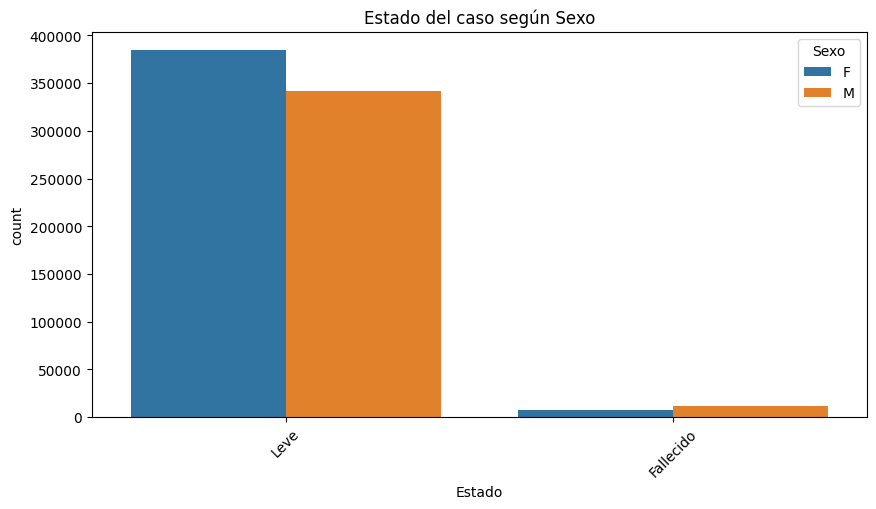

In [157]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Estado', hue='Sexo')
plt.title('Estado del caso según Sexo')
plt.xticks(rotation=45)
plt.show()

Al analizar la variable sexo con estado (nivel de enfermedad) podemos ver que la mayoria de los casos leves fueron casos de mujeres, y la mayoria de fallecidos fueron hombre,

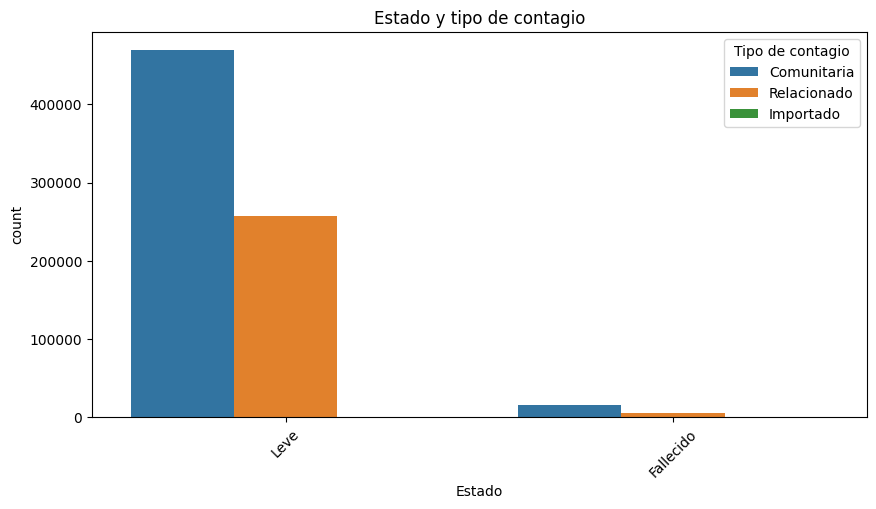

In [158]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Estado', hue='Tipo de contagio')
plt.title('Estado y tipo de contagio')
plt.xticks(rotation=45)
plt.show()

podemos identificar que la mayoria de los contagios leves, fueron por contagio comunitario. No se idenfitica el importado como causa leve. Igualmente la mayoria de los fallecidos, fieron por contagio comunitario, pero esto se explica ya que la mayoria de contagios lo fueron, por lo tanto se explica esta relacion directa entre fallecido y tipo de contagio comunitario.

In [159]:
# Crear rangos de edad de 10 en 10
bins = range(0, int(df['Edad'].max()) + 11, 10)  # ajusta el +11 si quieres que cierre bien el último rango
labels = [f'{i}-{i+9}' for i in bins[:-1]]

df['Rango_edad'] = pd.cut(df['Edad'], bins=bins, labels=labels, right=False)

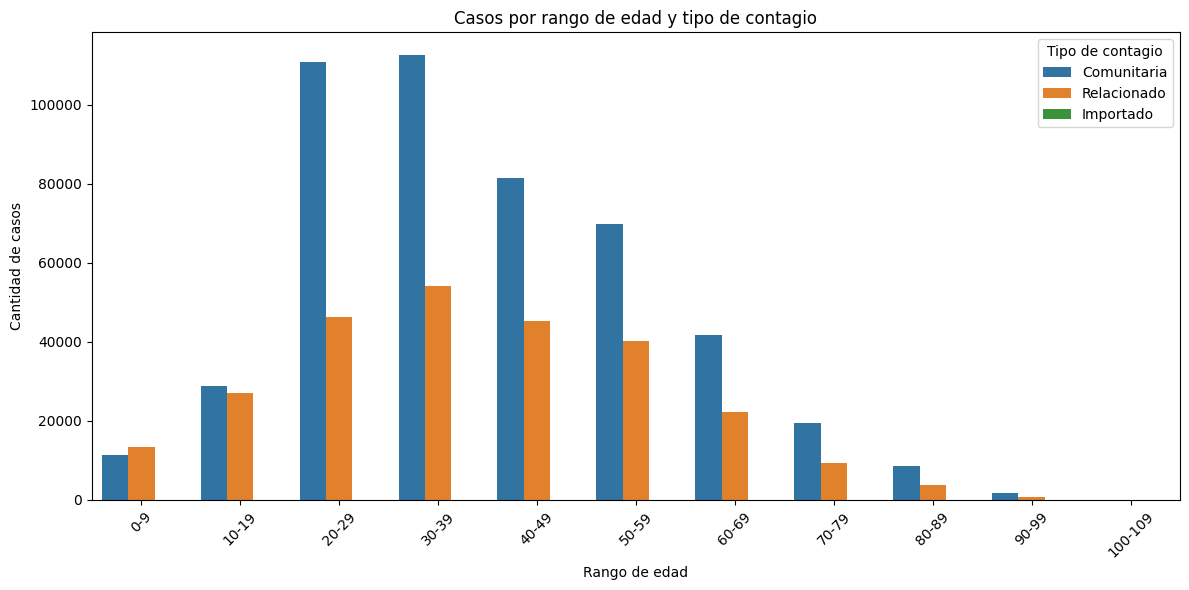

In [160]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Rango_edad', hue='Tipo de contagio', order=labels)
plt.title('Casos por rango de edad y tipo de contagio')
plt.xlabel('Rango de edad')
plt.ylabel('Cantidad de casos')
plt.xticks(rotation=45)
plt.legend(title='Tipo de contagio')
plt.tight_layout()
plt.show()

Podemos identificar que la mayoria de contagios, siguen siendo por medio comunitaria, pero se ve mas aun en la edad de 20- 59, lo que corresponde a la edad productiva (fuerza de trabajo) en la mayoria de paises. Es decir que podemos relacionar que la mayoria de casos, pueden ser referentes a la presencialidad del trabajo, o la vida social que se realiza en entornos sociales.

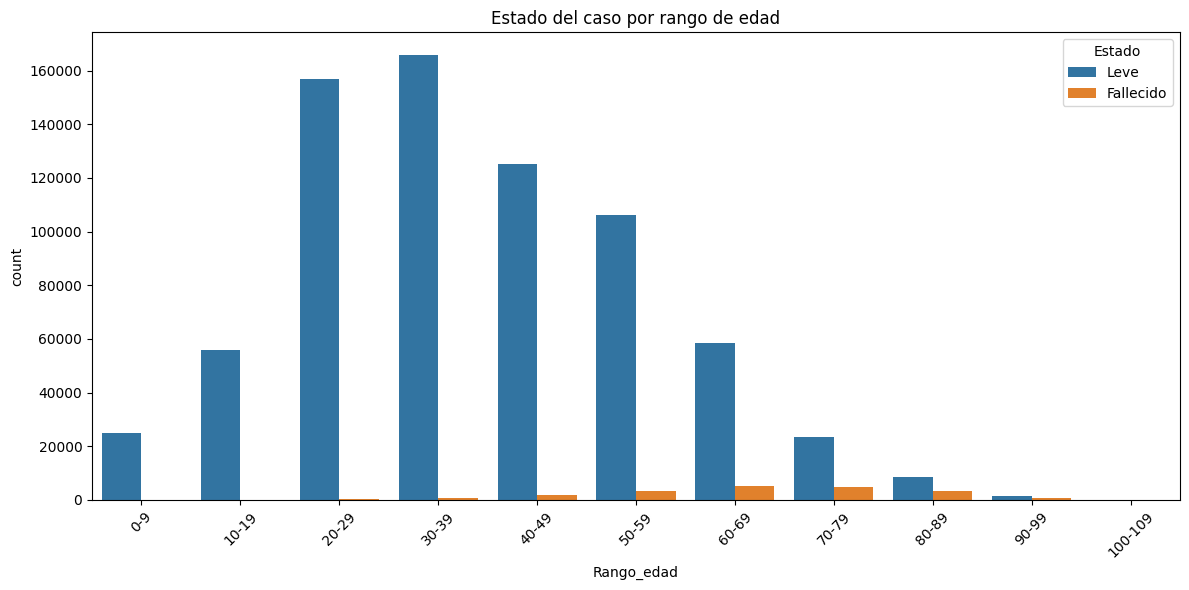

In [161]:
#analisis de edad con rango de edad

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Rango_edad', hue='Estado', order=labels)
plt.title('Estado del caso por rango de edad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Se identifica que la mayoria de las muertes, se dan en edades mayoes ( de 50- 99), sin embargo en edades temprandas de 0-40 se ve una tendencia a casos leves. Es decir, hay mayor probabilidad de muerte con mayor rango de edad.

Estado  Fallecido   Leve
Sexo                    
F            2.01  97.99
M            3.40  96.60


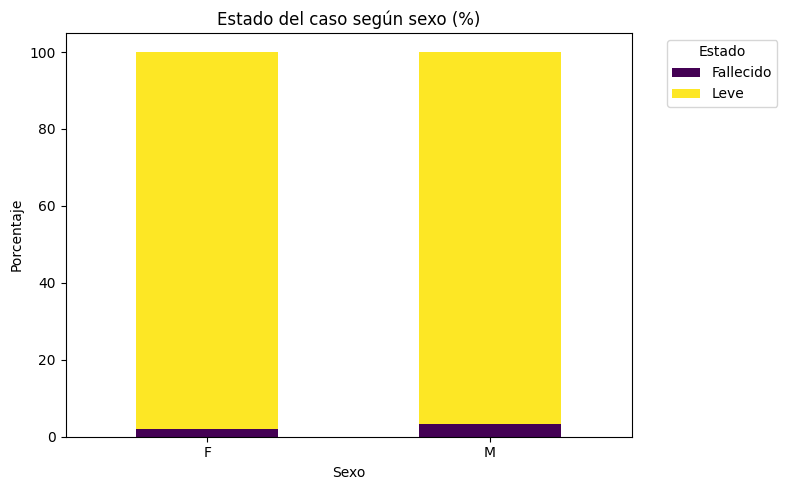

In [162]:
#gravedad o estado por genero.

tabla = pd.crosstab(df['Sexo'], df['Estado'], normalize='index') * 100
print(tabla.round(2))

tabla.plot(kind='bar', stacked=True, figsize=(8, 5), colormap='viridis')
plt.title('Estado del caso según sexo (%)')
plt.ylabel('Porcentaje')
plt.xticks(rotation=0)
plt.legend(title='Estado', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

Se identifican mas fallecidos del genero Masculino.

/tmp/ipykernel_632/2976668853.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_dept.values, y=top_dept.index, palette='rocket')


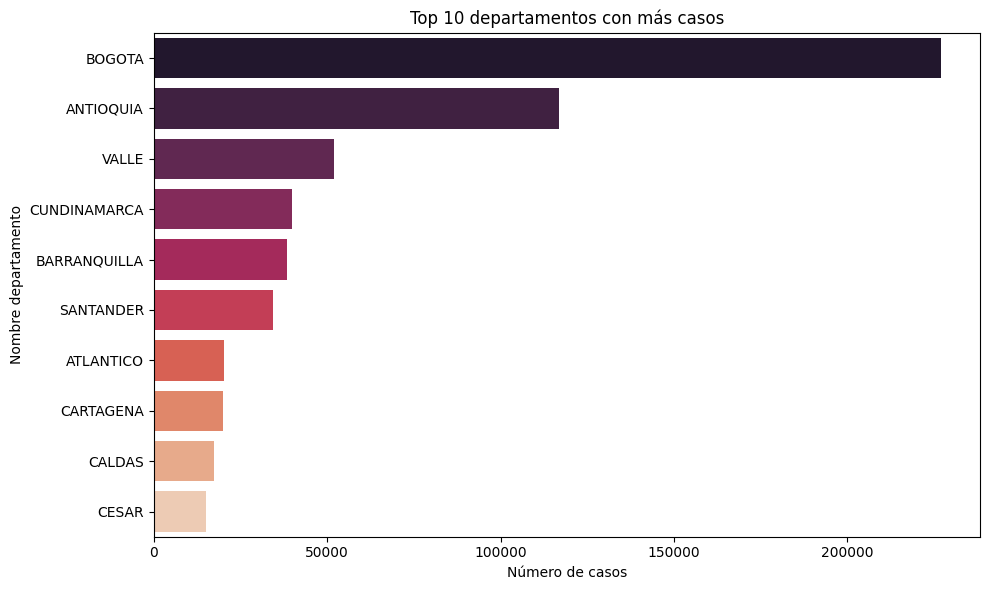

In [163]:
#casos por departamento - Analisis de afectacion por zona geografica
plt.figure(figsize=(10, 6))
top_dept = df['Nombre departamento'].value_counts().head(10)
sns.barplot(x=top_dept.values, y=top_dept.index, palette='rocket')
plt.title('Top 10 departamentos con más casos')
plt.xlabel('Número de casos')
plt.tight_layout()
plt.show()

Los departamentos mas fectados con casos de covid, fueron bogota, y luego Antioquia, lo que determina que la mayoria de afectaciones fuero en la capital del pais, pasando por mucho la cifra de antioquia. Esto tambien se puede determinar por variables sociales, ya que bogota tiene un numero de habitantes mayor a las otras cuidades de colombia, por ende tiene sentido que la mayoria de casos fueran registrados en Bogota.

Ubicación del caso  CASA    Casa  Fallecido  casa
Tipo de contagio                                 
Comunitaria            1  468611      15169   614
Importado              0     231         10     1
Relacionado            4  256903       4759   165


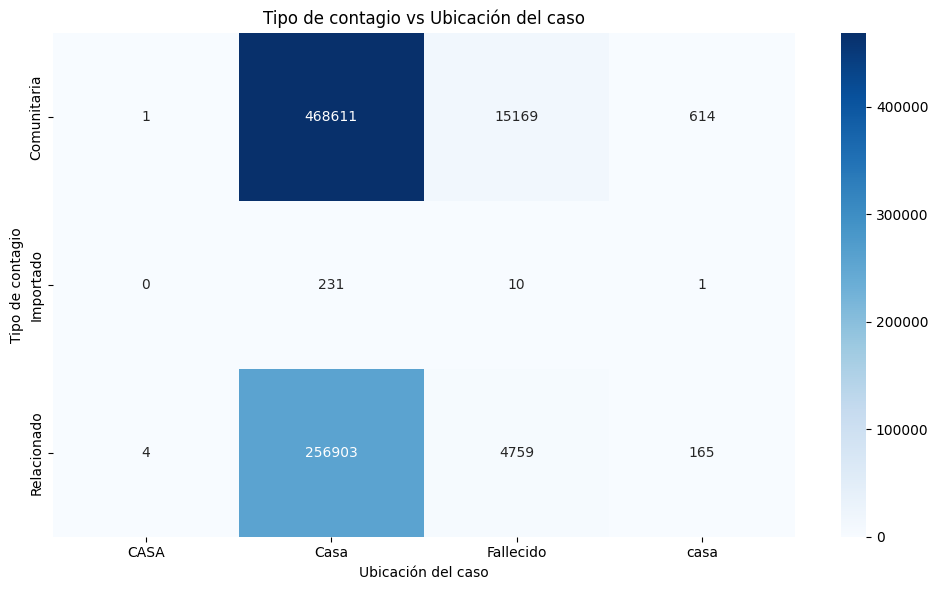

In [164]:
# Departamento vs Estado
top_5_dept = df['Nombre departamento'].value_counts().head(5).index
subset = df[df['Nombre departamento'].isin(top_5_dept)]

tabla = pd.crosstab(df['Tipo de contagio'], df['Ubicación del caso'])
print(tabla)

plt.figure(figsize=(10, 6))
sns.heatmap(tabla, annot=True, fmt='d', cmap='Blues')
plt.title('Tipo de contagio vs Ubicación del caso')
plt.tight_layout()
plt.show()


Se identifica una asocacion "perfecta" entre sexo y estado, pero es solo una rebundancia en este caso, el resto de asociaciones se considera insignificante (no hay relacion)

Analisis de fechas

In [165]:
#estandarizacion de formato fechas en caso de que queremos anaizar algo relacionado con fehcas debemos estandarizar el formato
columnas_fecha = ['fecha reporte web', 'Fecha de notificación', 'Fecha de inicio de síntomas',
                   'Fecha de muerte', 'Fecha de diagnóstico', 'Fecha de recuperación']

for col in columnas_fecha:
    df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)

/tmp/ipykernel_632/2157670068.py:6: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)
/tmp/ipykernel_632/2157670068.py:6: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)
/tmp/ipykernel_632/2157670068.py:6: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df[col] = pd.to_datetime(df[col], errors='coerce', dayfirst=True)
/tmp/ipykernel_632/2157670068.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.


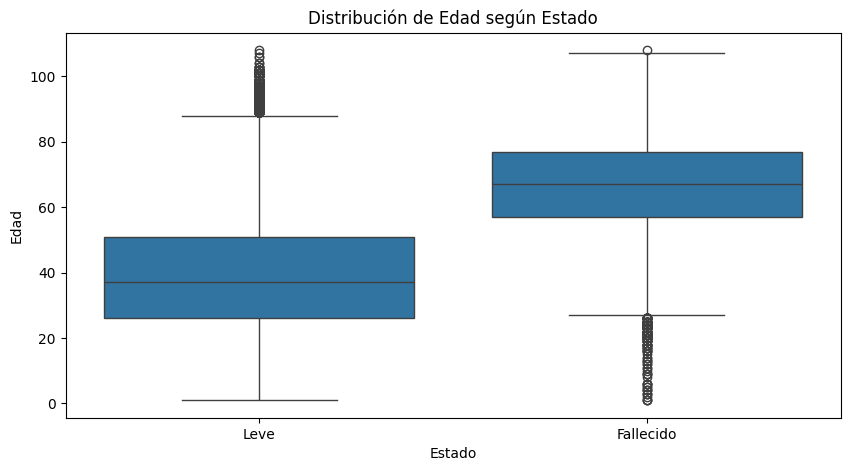

In [166]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Estado', y='Edad')  # ajusta el nombre de la columna numérica
plt.title('Distribución de Edad según Estado')
plt.show()

El promedio de fallecidos, tenian una edad de 77 años, como la media. En los casos graves tambien vemos una edad avanzada de la media.


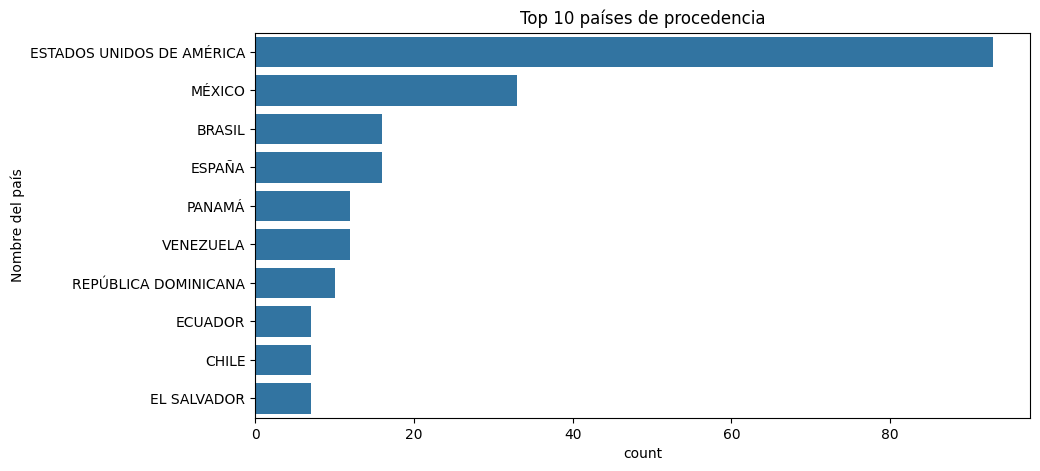

In [167]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='Nombre del país', order=df['Nombre del país'].value_counts().index[:10])
plt.title('Top 10 países de procedencia')
plt.show()

In [168]:
df.groupby('Estado')['Edad'].describe()

,count,mean,std,min,25%,50%,75%,max
Estado,,,,,,,,
Fallecido,19938.0,66.187832,15.098994,1.0,57.0,67.0,77.0,108.0
Leve,726530.0,38.791378,17.126458,1.0,26.0,37.0,51.0,108.0


La mayoria de los casos registrados en nuestro data set son provenientes de USA.

Descriptiva

In [169]:

# Numéricas
df.describe().T

,count,mean,min,25%,50%,75%,max,std
fecha reporte web,749694,2021-03-04 16:23:27.742358528,2020-05-11 00:00:00,2020-12-11 00:00:00,2021-04-23 00:00:00,2021-05-29 00:00:00,2022-01-25 00:00:00,NaN
Fecha de notificación,749694,2021-02-25 06:40:13.675980032,2020-03-21 00:00:00,2020-12-03 00:00:00,2021-04-16 00:00:00,2021-05-24 00:00:00,2022-01-23 00:00:00,NaN
Edad,749694.0,39.635665,1.0,27.0,38.0,52.0,108.0,17.730217
Unidad de medida de edad,749694.0,1.003345,1.0,1.0,1.0,1.0,3.0,0.062576
Fecha de inicio de síntomas,749422,2021-03-01 11:24:57.823122944,2020-04-06 00:00:00,2020-12-07 00:00:00,2021-04-20 00:00:00,2021-05-27 00:00:00,2022-01-24 00:00:00,NaN
Fecha de diagnóstico,324417,2021-03-22 22:02:31.205393152,2020-01-06 00:00:00,2021-01-06 00:00:00,2021-04-06 00:00:00,2021-08-04 00:00:00,2022-12-01 00:00:00,NaN
Fecha de muerte,0,NaT,NaT,NaT,NaT,NaT,NaT,NaN
Fecha de recuperación,0,NaT,NaT,NaT,NaT,NaT,NaT,NaN


In [170]:
# Categóricas
categoricas = df.select_dtypes(include=['object', 'category']).columns
for col in categoricas:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(10))


--- ID de caso ---
ID de caso
3,514,865    1
1,556,979    1
1,556,980    1
1,556,981    1
1,556,982    1
1,556,983    1
1,556,984    1
1,556,985    1
1,556,986    1
1,556,987    1
Name: count, dtype: int64

--- Código DIVIPOLA departamento ---
Código DIVIPOLA departamento
11        226941
5         116814
76         51938
25         39856
8,001      38324
68         34516
8          20375
13,001     19950
17         17443
20         15132
Name: count, dtype: int64

--- Nombre departamento ---
Nombre departamento
BOGOTA          226941
ANTIOQUIA       116814
VALLE            51938
CUNDINAMARCA     39856
BARRANQUILLA     38324
SANTANDER        34516
ATLANTICO        20375
CARTAGENA        19950
CALDAS           17442
CESAR            15132
Name: count, dtype: int64

--- Código DIVIPOLA municipio ---
Código DIVIPOLA municipio
11,001    226941
5,001      63467
8,001      38324
76,001     33211
13,001     19950
68,001     16093
17,001     12334
20,001     10745
47,001     10133
8,758      

In [171]:
# Categóricas
categoricas = df.select_dtypes(include=['object', 'category']).columns
for col in categoricas:
    print(f"\n--- {col} ---")
    print(df[col].value_counts().head(10))


--- ID de caso ---
ID de caso
3,514,865    1
1,556,979    1
1,556,980    1
1,556,981    1
1,556,982    1
1,556,983    1
1,556,984    1
1,556,985    1
1,556,986    1
1,556,987    1
Name: count, dtype: int64

--- Código DIVIPOLA departamento ---
Código DIVIPOLA departamento
11        226941
5         116814
76         51938
25         39856
8,001      38324
68         34516
8          20375
13,001     19950
17         17443
20         15132
Name: count, dtype: int64

--- Nombre departamento ---
Nombre departamento
BOGOTA          226941
ANTIOQUIA       116814
VALLE            51938
CUNDINAMARCA     39856
BARRANQUILLA     38324
SANTANDER        34516
ATLANTICO        20375
CARTAGENA        19950
CALDAS           17442
CESAR            15132
Name: count, dtype: int64

--- Código DIVIPOLA municipio ---
Código DIVIPOLA municipio
11,001    226941
5,001      63467
8,001      38324
76,001     33211
13,001     19950
68,001     16093
17,001     12334
20,001     10745
47,001     10133
8,758      

##Conclusiòn de los hallazgos

Con este analisis estadistito podemos objeter datos como la media, mediana, conteo general, desviacion estandar y cuatiles en un mismo analisis, lo cua nos deja ver que clase de dataset tenemos pero tambien, un analisis a fondo de los datos encontrados en toda la sabana.

De esta manera podemos identificar la correlacion de variables, identificando posibles causales para las demas, llegando a una correlacion estadistica.

## Perfilado de datos

In [172]:
#instalar libreria para perfilado de datos
!pip install ydata-profiling --quiet

In [173]:
# Instalar la nueva librería fg-data-profiling
!pip install fg-data-profiling --quiet

In [174]:
import pandas as pd
from ydata_profiling import ProfileReport

In [175]:

#perfil = ProfileReport(df, title="Perfil de datos", explorative=True)
#perfil.to_file("Perfil.html")

#print("Perfil exportado correctamente como 'Perfil.html'")

conclusiones:
Desde el perfilado de datos, tenemos un análisis estadístico de todas las categorías, cada una de las variables y la calidad de los datos.
Este nos permite así, tener un HTML explicativo de nuestro dataset, conteniendo, media, moda, frecuencia, y conteo de cada variable.
Por medio de este perfil logramos entonces, analizar el dataset y tomar decisiones antes de comenzar a explorar, reconociendo un análisis exploratorio de datos.

Por medio de este perfil identificamos:
1. Tenemos un conjunto de 6.390.971 registros de los cuales 23 son variables con 0% de filas duplicadas, aun así el 17.9% de celdas están vacías.

2. No hay valores infinitos, ni negativos ni en cero, lo cual garantiza que es una variable numérica y que el dato o el contenido es contenido real y limpio.

3. Se identifican que los datos faltantes corresponden al Código ISO de cada país, teniendo un 99% vacíos en este caso, sin embargo conociendo el dataset, este dato podemos tomarlo de la variable país por lo cual no nos afecta la interpretación.

4. Se evidencian 5 posibles correlaciones, que muestran relación en departamento, código, nombre de estado, recuperado, tipo de recuperación y ubicación del caso. Lo cual nos determina lo que se menciona en el punto 3, hay muchos datos que muestran la misma información, esto muestra redundancia de información en nuestro DB.

5. Existen dos variables que están dominadas por una sola categoría que son:
- Ubicación del caso
- Estado de recuperación

6. La mayoría de los casos fueron leves, lo cual es bueno en la vida real, pero crea una cantidad de datos enorme de casos leves que pueden no ser una muestra aleatoria del caso.


# Entrega 2 - Limpeza de datos

In [176]:
df.columns

Index(['fecha reporte web', 'ID de caso', 'Fecha de notificación',
       'Código DIVIPOLA departamento', 'Nombre departamento',
       'Código DIVIPOLA municipio', 'Nombre municipio', 'Edad',
       'Unidad de medida de edad', 'Sexo', 'Tipo de contagio',
       'Ubicación del caso', 'Estado', 'Código ISO del país',
       'Nombre del país', 'Pertenencia étnica', 'Nombre del grupo étnico',
       'Tipo de recuperación', 'Fecha de inicio de síntomas',
       'Fecha de diagnóstico', 'Fecha de muerte', 'Fecha de recuperación',
       'Extra_Column', 'Rango_edad'],
      dtype='object')

In [177]:
print()

In [178]:
# Instalar una biblioteca de Python (ejemplo: requests)
!pip install requests

Después de ejecutar la celda, la biblioteca se instalará y podrás importarla y usarla en tu notebook:

In [179]:
import requests

# Ahora puedes usar la biblioteca requests
response = requests.get('https://www.google.com')
print(response.status_code)

200


Ver datos por columna con Count, generamos una fucion para no hacerlo manual con el value_count y que salgan automaticamente el conteo - Revision general para confirmar que los datos por cada nombre de columna esten bien

In [180]:
columns_to_show_counts = [
    'Estado', 'Ubicación del caso', 'Sexo', 'Tipo de contagio',
    'Nombre del país', 'Tipo de recuperación', 'Pertenencia étnica', 'Nombre del grupo étnico'
]

for col in columns_to_show_counts:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- Estado ---
Estado
Leve         726530
Fallecido     19938
NaN            3226
Name: count, dtype: int64

--- Ubicación del caso ---
Ubicación del caso
Casa         725745
Fallecido     19938
NaN            3226
casa            780
CASA              5
Name: count, dtype: int64

--- Sexo ---
Sexo
F    393613
M    356081
Name: count, dtype: int64

--- Tipo de contagio ---
Tipo de contagio
Comunitaria    486778
Relacionado    262674
Importado         242
Name: count, dtype: int64

--- Nombre del país ---
Nombre del país
NaN                                     749451
ESTADOS UNIDOS DE AMÉRICA                   93
MÉXICO                                      33
BRASIL                                      16
ESPAÑA                                      16
PANAMÁ                                      12
VENEZUELA                                   12
REPÚBLICA DOMINICANA                        10
ECUADOR                                      7
CHILE                                        7
EL 

Limpieza de datos (data cleaning)

Utiliza value_counts(dropna=False), para visualizar las siguientes variables: Estado, Atención, Sexo, Tipo, País_procedencia, Tipo_recuperación, Pertenencia_étnica, Nombre_grupo_étnico

Análisis de la variable 'Estado'

In [181]:
df['Estado'].unique()

array(['Leve', 'Fallecido', nan], dtype=object)

In [182]:
estado_sucio=df['Estado'].unique()
print(estado_sucio)

['Leve' 'Fallecido' nan]


In [183]:
municipio_ok=['Leve', 'Fallecido', 'Desconocido']

In [184]:
#print para mostrar variable estado con el conteo general y el uso de dro false
print(df['Estado'].value_counts(dropna=False))

Estado
Leve         726530
Fallecido     19938
NaN            3226
Name: count, dtype: int64


No se indentifican datos nulos en este caso

Análisis de la variable 'Atención' no existe, usaremos la de ubicacion del caso



In [185]:
df['Ubicación del caso'].unique()

array(['Casa', 'Fallecido', nan, 'casa', 'CASA'], dtype=object)

In [186]:
ubicacion_sucio=df['Ubicación del caso'].unique()
print(ubicacion_sucio)

['Casa' 'Fallecido' nan 'casa' 'CASA']


In [187]:
#print para mostrar variable con el conteo general y el uso de dro false

print(df['Ubicación del caso'].value_counts(dropna=False))

Ubicación del caso
Casa         725745
Fallecido     19938
NaN            3226
casa            780
CASA              5
Name: count, dtype: int64


No se indentifican datos nulos en este caso

Análisis de la variable 'Sexo'

In [188]:
df['Sexo'].unique()

array(['F', 'M'], dtype=object)

In [189]:
sexo_sucio=df['Sexo'].unique()
print(sexo_sucio)

['F' 'M']


In [190]:
#print para mostrar variable con el conteo general y el uso de dro false

print(df['Sexo'].value_counts(dropna=False))

Sexo
F    393613
M    356081
Name: count, dtype: int64


No se indentifican datos nulos en este caso

Análisis de la variable 'Tipo'

In [191]:
df['Tipo de contagio'].unique()

array(['Comunitaria', 'Relacionado', 'Importado'], dtype=object)

In [192]:
tipo_sucio=df['Tipo de contagio'].unique()
print(tipo_sucio)

['Comunitaria' 'Relacionado' 'Importado']


In [193]:
#print para mostrar variable con el conteo general y el uso de dro false


print(df['Tipo de contagio'].value_counts(dropna=False))

Tipo de contagio
Comunitaria    486778
Relacionado    262674
Importado         242
Name: count, dtype: int64


No se indentifican datos nulos en este caso

Análisis de la variable 'País_procedencia'

In [194]:
nombre_sucio=df['Nombre del país'].unique()
print(nombre_sucio)

[nan 'MÉXICO' 'REPÚBLICA DOMINICANA' 'ALEMANIA' 'FRANCIA'
 'ESTADOS UNIDOS DE AMÉRICA' 'ECUADOR' 'PORTUGAL' 'BRASIL' 'EL SALVADOR'
 'PANAMÁ' 'EMIRATOS ARABES UNIDOS' 'ARMENIA' 'DOMINICA' 'NORUEGA' 'PERÚ'
 'ESPAÑA' 'INDONESIA' 'VENEZUELA' 'CHILE' 'TRINIDAD Y TOBAGO' 'NICARAGUA'
 'PERU' 'ISLAS VÍRGENES DE LOS ESTADOS UNIDOS' 'ARGENTINA' 'ITALIA'
 'CURAZAO' 'PUERTO RICO' 'EGIPTO' 'FEDERACIÓN DE RUSIA' 'CANADÁ'
 'GUATEMALA']


In [195]:
nombre_sucio

array([nan, 'MÉXICO', 'REPÚBLICA DOMINICANA', 'ALEMANIA', 'FRANCIA',
       'ESTADOS UNIDOS DE AMÉRICA', 'ECUADOR', 'PORTUGAL', 'BRASIL',
       'EL SALVADOR', 'PANAMÁ', 'EMIRATOS ARABES UNIDOS', 'ARMENIA',
       'DOMINICA', 'NORUEGA', 'PERÚ', 'ESPAÑA', 'INDONESIA', 'VENEZUELA',
       'CHILE', 'TRINIDAD Y TOBAGO', 'NICARAGUA', 'PERU',
       'ISLAS VÍRGENES DE LOS ESTADOS UNIDOS', 'ARGENTINA', 'ITALIA',
       'CURAZAO', 'PUERTO RICO', 'EGIPTO', 'FEDERACIÓN DE RUSIA',
       'CANADÁ', 'GUATEMALA'], dtype=object)

In [196]:
#print para mostrar variable con el conteo general y el uso de dro false

print(df['Nombre del país'].value_counts(dropna=False))

Nombre del país
NaN                                     749451
ESTADOS UNIDOS DE AMÉRICA                   93
MÉXICO                                      33
BRASIL                                      16
ESPAÑA                                      16
PANAMÁ                                      12
VENEZUELA                                   12
REPÚBLICA DOMINICANA                        10
ECUADOR                                      7
CHILE                                        7
EL SALVADOR                                  7
PERÚ                                         5
ARMENIA                                      2
EMIRATOS ARABES UNIDOS                       2
FRANCIA                                      2
PORTUGAL                                     2
PERU                                         2
NORUEGA                                      1
ALEMANIA                                     1
DOMINICA                                     1
INDONESIA                                   

In [197]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 749694 entries, 1 to 749694
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   fecha reporte web             749694 non-null  datetime64[ns]
 1   ID de caso                    749694 non-null  object        
 2   Fecha de notificación         749694 non-null  datetime64[ns]
 3   Código DIVIPOLA departamento  749694 non-null  object        
 4   Nombre departamento           749694 non-null  object        
 5   Código DIVIPOLA municipio     749694 non-null  object        
 6   Nombre municipio              749694 non-null  object        
 7   Edad                          749694 non-null  int64         
 8   Unidad de medida de edad      749694 non-null  int64         
 9   Sexo                          749694 non-null  object        
 10  Tipo de contagio              749694 non-null  object        
 11  Ubicación del

In [198]:
print(df['Nombre municipio'].value_counts(dropna=False))

Nombre municipio
BOGOTA                           226941
MEDELLIN                          63466
BARRANQUILLA                      38324
CALI                              33211
CARTAGENA                         19950
                                  ...  
RONDON                                1
Pensilvania                           1
FRANCISCO PIZARRO (SALAHONDA)         1
MACARAVITA                            1
SAN FELIPE (CD)                       1
Name: count, Length: 1030, dtype: int64


No se indentifican datos nulos en este caso

 Análisis de la variable 'Tipo_recuperación'

In [199]:
df['Tipo de recuperación'].unique()

array([nan, '2020-12-30 00:00:00', '2020-12-26 00:00:00',
       '2020-11-11 00:00:00', '2020-11-12 00:00:00',
       '2020-11-16 00:00:00', '2020-12-23 00:00:00',
       '2021-01-09 00:00:00', '2020-08-10 00:00:00',
       '2020-07-24 00:00:00', '2020-07-29 00:00:00',
       '2020-08-07 00:00:00', '2020-08-08 00:00:00',
       '2021-01-24 00:00:00', '2020-07-23 00:00:00',
       '2022-02-27 00:00:00', '2020-08-01 00:00:00',
       '2021-01-17 00:00:00', '2020-10-10 00:00:00',
       '2020-07-03 00:00:00', '2020-09-28 00:00:00',
       '2020-10-07 00:00:00', '2021-05-17 00:00:00',
       '2020-10-04 00:00:00', '2020-09-15 00:00:00',
       '2020-06-20 00:00:00', '2020-07-11 00:00:00',
       '2020-06-30 00:00:00', '2021-01-10 00:00:00',
       '2021-01-18 00:00:00', '2021-01-26 00:00:00',
       '2021-01-14 00:00:00', '2021-02-12 00:00:00',
       '2021-01-07 00:00:00', '2021-01-12 00:00:00',
       '2021-01-22 00:00:00', '2021-01-08 00:00:00',
       '2021-01-23 00:00:00', '2021-02-08

In [200]:
#print para mostrar variable con el conteo general y el uso de dro false

print(df['Tipo de recuperación'].value_counts(dropna=False))

Tipo de recuperación
NaN                    726530
2021-06-05 00:00:00       268
2021-06-03 00:00:00       261
2021-06-02 00:00:00       254
2021-04-26 00:00:00       249
                        ...  
2020-04-30 00:00:00         1
2020-05-03 00:00:00         1
2020-05-06 00:00:00         1
2022-01-01 00:00:00         1
2021-11-17 00:00:00         1
Name: count, Length: 652, dtype: int64


No se indentifican datos nulos en este caso

Análisis de la variable


'Pertenencia_étnica'

In [201]:
df['Pertenencia étnica'].unique()

array(['Recuperado', 'Fallecido', nan, 'fallecido'], dtype=object)

In [202]:
#print para mostrar variable con el conteo general y el uso de dro false

print(df['Pertenencia étnica'].value_counts(dropna=False))

Pertenencia étnica
Recuperado    727102
Fallecido      19917
NaN             2654
fallecido         21
Name: count, dtype: int64


No se indentifican datos nulos en este caso

Análisis de la variable 'Nombre_grupo_étnico'

In [203]:
#print para mostrar variable con el conteo general y el uso de dro false

print(df['Pertenencia étnica'].value_counts(dropna=False))

Pertenencia étnica
Recuperado    727102
Fallecido      19917
NaN             2654
fallecido         21
Name: count, dtype: int64


In [204]:
#print paa mostrar variables de contedo

print (df['Nombre del grupo étnico'].value_counts(dropna=False))

Nombre del grupo étnico
NaN                    77003
2021-05-20 00:00:00    16238
2021-05-21 00:00:00    13867
2021-05-19 00:00:00    12633
2021-05-22 00:00:00    11720
                       ...  
2022-01-03 00:00:00        1
2021-12-30 00:00:00        1
2021-12-31 00:00:00        1
2021-09-12 00:00:00        1
2021-12-11 00:00:00        1
Name: count, Length: 549, dtype: int64


No se indentifican datos nulos en este caso

In [205]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 749694 entries, 1 to 749694
Data columns (total 24 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   fecha reporte web             749694 non-null  datetime64[ns]
 1   ID de caso                    749694 non-null  object        
 2   Fecha de notificación         749694 non-null  datetime64[ns]
 3   Código DIVIPOLA departamento  749694 non-null  object        
 4   Nombre departamento           749694 non-null  object        
 5   Código DIVIPOLA municipio     749694 non-null  object        
 6   Nombre municipio              749694 non-null  object        
 7   Edad                          749694 non-null  int64         
 8   Unidad de medida de edad      749694 non-null  int64         
 9   Sexo                          749694 non-null  object        
 10  Tipo de contagio              749694 non-null  object        
 11  Ubicación del

In [206]:
df.set_index('Código DIVIPOLA departamento', inplace=True)

Corroboramos que no hay datos nulos en ninguna varuable

In [207]:
df.head()

,fecha reporte web,ID de caso,Fecha de notificación,Nombre departamento,Código DIVIPOLA municipio,Nombre municipio,Edad,Unidad de medida de edad,Sexo,Tipo de contagio,...,Nombre del país,Pertenencia étnica,Nombre del grupo étnico,Tipo de recuperación,Fecha de inicio de síntomas,Fecha de diagnóstico,Fecha de muerte,Fecha de recuperación,Extra_Column,Rango_edad
Código DIVIPOLA departamento,,,,,,,,,,,,,,,,,,,,,
76,2020-12-24,"1,556,979",2020-12-22,VALLE,"76,001",CALI,67,1,F,Comunitaria,...,NaN,Recuperado,2020-12-21 00:00:00,NaN,2020-12-23,2021-04-01,NaT,NaT,NaN,60-69
76,2020-12-24,"1,556,980",2020-12-19,VALLE,"76,001",CALI,66,1,F,Comunitaria,...,NaN,Recuperado,2020-12-07 00:00:00,NaN,2020-12-23,NaT,NaT,NaT,NaN,60-69
76,2020-12-24,"1,556,981",2020-12-19,VALLE,"76,001",CALI,68,1,F,Comunitaria,...,NaN,Recuperado,2020-12-18 00:00:00,NaN,2020-12-22,2021-01-01,NaT,NaT,NaN,60-69
76,2020-12-24,"1,556,982",2020-12-22,VALLE,"76,001",CALI,74,1,F,Comunitaria,...,NaN,Fallecido,2020-12-17 00:00:00,2020-12-30 00:00:00,2020-12-23,NaT,NaT,NaT,NaN,70-79
76,2020-12-24,"1,556,983",2020-12-22,VALLE,"76,001",CALI,65,1,F,Comunitaria,...,NaN,Recuperado,2020-12-21 00:00:00,NaN,2020-12-23,2021-04-01,NaT,NaT,NaN,60-69


In [208]:
#orden de DF por index - Por defecto ordena de forma ascendente
df.sort_index()

,fecha reporte web,ID de caso,Fecha de notificación,Nombre departamento,Código DIVIPOLA municipio,Nombre municipio,Edad,Unidad de medida de edad,Sexo,Tipo de contagio,...,Nombre del país,Pertenencia étnica,Nombre del grupo étnico,Tipo de recuperación,Fecha de inicio de síntomas,Fecha de diagnóstico,Fecha de muerte,Fecha de recuperación,Extra_Column,Rango_edad
Código DIVIPOLA departamento,,,,,,,,,,,,,,,,,,,,,
11,2021-06-04,"3,514,865",2021-05-27,BOGOTA,"11,001",BOGOTA,13,1,M,Relacionado,...,NaN,Recuperado,2021-05-19 00:00:00,NaN,NaT,NaT,NaT,NaT,NaN,10-19
11,2020-12-18,"1,476,966",2020-12-15,BOGOTA,"11,001",BOGOTA,50,1,F,Comunitaria,...,NaN,Recuperado,2020-12-03 00:00:00,NaN,2020-12-17,NaT,NaT,NaT,NaN,50-59
11,2020-12-18,"1,476,967",2020-12-15,BOGOTA,"11,001",BOGOTA,50,1,F,Comunitaria,...,NaN,Recuperado,NaN,NaN,2020-12-16,NaT,NaT,NaT,NaN,50-59
11,2020-12-18,"1,476,968",2020-12-15,BOGOTA,"11,001",BOGOTA,50,1,F,Relacionado,...,NaN,Recuperado,2020-12-10 00:00:00,NaN,2020-12-16,NaT,NaT,NaT,NaN,50-59
11,2020-12-18,"1,476,969",2020-12-15,BOGOTA,"11,001",BOGOTA,50,1,F,Relacionado,...,NaN,Recuperado,2020-12-15 00:00:00,NaN,2020-12-16,NaT,NaT,NaT,NaN,50-59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,2021-06-06,"3,555,744",2021-06-01,VICHADA,"99,001",PUERTO CARREÑO,23,1,M,Comunitaria,...,NaN,Recuperado,2021-05-29 00:00:00,NaN,2021-06-04,2021-12-06,NaT,NaT,NaN,20-29
99,2021-06-05,"3,519,290",2021-05-24,VICHADA,"99,001",PUERTO CARREÑO,54,1,F,Comunitaria,...,NaN,Recuperado,2021-05-20 00:00:00,NaN,2021-06-04,2021-06-06,NaT,NaT,NaN,50-59
99,2021-04-30,"2,845,561",2021-04-19,VICHADA,"99,001",PUERTO CARREÑO,32,1,F,Comunitaria,...,NaN,Recuperado,2021-04-15 00:00:00,NaN,2021-04-26,2021-01-05,NaT,NaT,NaN,30-39


Realiza una limpieza de datos de las variables


anteriores, haciendo uso de .zip(), .map(), .replace(), .fillna(), etc.


Limpieza de la variable 'Estado' - Decodificacion de las variables

In [209]:
# Estandarizar variable: Convertir a minúsculas, eliminar espacios y reemplazar valores comunes.
df.loc[:, 'Estado'] = df['Estado'].astype(str).str.lower().str.strip()
estado_mapeo = {
    'leve': 'Leve',
    'fallecido': 'Fallecido',
    'nan': 'Desconocido'
}
df.loc[:, 'Estado'] = df['Estado'].map(estado_mapeo).fillna('Desconocido')

print(df['Estado'].value_counts(dropna=False))

Estado
Leve           726530
Fallecido       19938
Desconocido      3226
Name: count, dtype: int64


En la variable estado, usamos el .map y el fillna, los NAn por desconocidos


Limpieza de la variable 'Atención'

In [210]:
# Estandarizar  variable Ubicación del caso: Convertir a minúsculas, eliminar espacios y reemplazar valores.
df.loc[:, 'Ubicación del caso'] = df['Ubicación del caso'].astype(str).str.lower().str.strip()
ubicacion_mapeo = {
    'casa': 'Casa',
    'hospital': 'Hospital',
    'uci': 'UCI',
    'fallecido': 'Desconocido',
    'nan': 'Desconocido'
}
df.loc[:, 'Ubicación del caso'] = df['Ubicación del caso'].map(ubicacion_mapeo).fillna('Desconocido')

print(df['Ubicación del caso'].value_counts(dropna=False))

Ubicación del caso
Casa           726530
Desconocido     23164
Name: count, dtype: int64


Cambiamos los fallecidos y los NAN por desconodos




Limpieza de la variable 'Sexo'

In [211]:
# Estandarizar variable Sexo: Convertir a mayúsculas, eliminar espacios y reemplazar valores.
df.loc[:, 'Sexo'] = df['Sexo'].str.upper().str.strip()
sexo_reemplazos = {
    'FEMENINO': 'F',
    'MASCULINO': 'M'
}
df.loc[:, 'Sexo'] = df['Sexo'].replace(sexo_reemplazos)
df.loc[:, 'Sexo'] = df['Sexo'].fillna('Desconocido')

print(df['Sexo'].value_counts(dropna=False))

Sexo
F    393613
M    356081
Name: count, dtype: int64


camviamos Femenimo por F y masculino por M para tener mejor manejo de datos

Limpieza de la variable 'Tipo'

In [212]:
# Estandarizar 'Tipo de contagio': Convertir a minúsculas, eliminar espacios y reemplazar valores.
df.loc[:, 'Tipo de contagio'] = df['Tipo de contagio'].astype(str).str.lower().str.strip()
contagio_mapeo = {
    'importado': 'Importado',
    'relacionado': 'Relacionado',
    'en estudio': 'En Estudio',
    'comunitaria': 'Comunitario',
    'nan': 'Desconocido'
}
df.loc[:, 'Tipo de contagio'] = df['Tipo de contagio'].map(contagio_mapeo).fillna('Desconocido')

print(df['Tipo de contagio'].value_counts(dropna=False))

Tipo de contagio
Comunitario    486778
Relacionado    262674
Importado         242
Name: count, dtype: int64


Cambiamos el nomnre de por la primera letra en Mayus, y nos nana por desconocido (aunque no hay en esta variable )

Limpieza de la variable 'País_procedencia'

In [213]:
# Estandarizar variable 'Nombre del país': Convertir a formato título, eliminar espacios y rellenar nulos.
# Primero, asegurar que la columna sea de tipo string/object para evitar el FutureWarning
df['Nombre del país'] = df['Nombre del país'].astype(str)

# Luego, aplicar las operaciones de string y reemplazar la cadena 'Nan'
df.loc[:, 'Nombre del país'] = df['Nombre del país'].str.title().str.strip().replace('Nan', 'Desconocido')

print(df['Nombre del país'].value_counts(dropna=False))

Nombre del país
Desconocido                             749451
Estados Unidos De América                   93
México                                      33
Brasil                                      16
España                                      16
Panamá                                      12
Venezuela                                   12
República Dominicana                        10
Ecuador                                      7
Chile                                        7
El Salvador                                  7
Perú                                         5
Armenia                                      2
Emiratos Arabes Unidos                       2
Francia                                      2
Portugal                                     2
Peru                                         2
Noruega                                      1
Alemania                                     1
Dominica                                     1
Indonesia                                   

usamos el Fillna para remplazar valores ausentes, remplazamos por desconocidos, luego hacemos un recuento, como es procedencia de pais lo remplazaremos por desconocido, no por cero

Limpieza de la variable 'Tipo_recuperación'

In [214]:
# Estandarizar variable tipo de recuperación': Convertir a minúsculas, eliminar espacios y reemplazar valores.
df.loc[:, 'Tipo de recuperación'] = df['Tipo de recuperación'].str.lower().str.strip()
recuperacion_reemplazos = {
    'recuperado': 'Recuperado',
    'fallecido': 'Fallecido'
}
df.loc[:, 'Tipo de recuperación'] = df['Tipo de recuperación'].replace(recuperacion_reemplazos)
df.loc[:, 'Tipo de recuperación'] = df['Tipo de recuperación'].fillna('Activo/Desconocido')

print(df['Tipo de recuperación'].value_counts(dropna=False))

Tipo de recuperación
Activo/Desconocido     726530
2021-06-05 00:00:00       268
2021-06-03 00:00:00       261
2021-06-02 00:00:00       254
2021-04-26 00:00:00       249
                        ...  
2020-04-30 00:00:00         1
2020-05-03 00:00:00         1
2020-05-06 00:00:00         1
2022-01-01 00:00:00         1
2021-11-17 00:00:00         1
Name: count, Length: 652, dtype: int64


Organizamos los nombres con mayus, vamos a agregar el Activo/desconocido.

Limpieza de la variable 'Pertenencia_étnica'

In [215]:
# Estandarizar variable Pertenencia étnica': Convertir a minúsculas, eliminar espacios y reemplazar valores.
df.loc[:, 'Pertenencia étnica'] = df['Pertenencia étnica'].astype(str).str.lower().str.strip()
etnica_mapeo = {
    'indígena': 'Indígena',
    'afrodescendiente': 'Afrodescendiente',
    'gitano': 'Gitano',
    'raizal': 'Raizal',
    'palenquero': 'Palenquero',
    'ninguna': 'Ninguna',
    '6.0': 'NA',
    '5.0': 'NA',
    '1.0': 'NA',
    '2.0': 'NA',
    '3.0': 'NA',
    'nan': 'No Registra'
}
df.loc[:, 'Pertenencia étnica'] = df['Pertenencia étnica'].map(etnica_mapeo).fillna('No Registra')

print(df['Pertenencia étnica'].value_counts(dropna=False))

Pertenencia étnica
No Registra    749694
Name: count, dtype: int64


Encontramos datos numericos en nuestra categoria variable. vamos a volverlos todos como NA

Limpieza de la variable 'Nombre_grupo_étnico'

In [216]:
# Estandarizar  variable 'Nombre del grupo étnico': Convertir a formato título, eliminar espacios y rellenar nulos.
df.loc[:, 'Nombre del grupo étnico'] = df['Nombre del grupo étnico'].str.title().str.strip()
df.loc[:, 'Nombre del grupo étnico'] = df['Nombre del grupo étnico'].fillna('No Aplica/Desconocido')

print(df['Nombre del grupo étnico'].value_counts(dropna=False))

Nombre del grupo étnico
No Aplica/Desconocido    77003
2021-05-20 00:00:00      16238
2021-05-21 00:00:00      13867
2021-05-19 00:00:00      12633
2021-05-22 00:00:00      11720
                         ...  
2022-01-03 00:00:00          1
2021-12-30 00:00:00          1
2021-12-31 00:00:00          1
2021-09-12 00:00:00          1
2021-12-11 00:00:00          1
Name: count, Length: 549, dtype: int64


Cambianos a NA/Desconocido en nombre Grupo Etnico

limpieza nombre de Nombre municipio

In [217]:
df.loc[:, 'Nombre municipio'] = df['Nombre municipio'].str.title().str.strip()
df.loc[:, 'Nombre municipio'] = df['Nombre municipio'].fillna('No Aplica/Desconocido')

print(df['Nombre municipio'].value_counts(dropna=False))

Nombre municipio
Bogota          226941
Medellin         63467
Barranquilla     38324
Cali             33211
Cartagena        19950
                 ...  
Tutaza               1
Jurado               1
El Dorado            1
Jerusalen            1
Villagomez           1
Name: count, Length: 1026, dtype: int64


Analicemos la variable nombre de departamentos

In [218]:
df.columns

Index(['fecha reporte web', 'ID de caso', 'Fecha de notificación',
       'Nombre departamento', 'Código DIVIPOLA municipio', 'Nombre municipio',
       'Edad', 'Unidad de medida de edad', 'Sexo', 'Tipo de contagio',
       'Ubicación del caso', 'Estado', 'Código ISO del país',
       'Nombre del país', 'Pertenencia étnica', 'Nombre del grupo étnico',
       'Tipo de recuperación', 'Fecha de inicio de síntomas',
       'Fecha de diagnóstico', 'Fecha de muerte', 'Fecha de recuperación',
       'Extra_Column', 'Rango_edad'],
      dtype='object')

In [219]:
print(df['Nombre departamento'].unique())

['VALLE' 'ANTIOQUIA' 'BOGOTA' 'SANTANDER' 'NORTE SANTANDER' 'CALDAS'
 'CUNDINAMARCA' 'CAQUETA' 'QUINDIO' 'RISARALDA' 'CASANARE' 'NARIÑO'
 'HUILA' 'CESAR' 'META' 'STA MARTA D.E.' 'TOLIMA' 'CAUCA' 'BARRANQUILLA'
 'SUCRE' 'CARTAGENA' 'BOLIVAR' 'GUAJIRA' 'ATLANTICO' 'CORDOBA' 'MAGDALENA'
 'ARAUCA' 'BOYACA' 'SAN ANDRES' 'CHOCO' 'GUAVIARE' 'VICHADA' 'PUTUMAYO'
 'VAUPES' 'GUAINIA' 'AMAZONAS' 'Caldas']


Elimina las siguientes variables del DataFrame utilizando la función 'Del': 'Código_DIVIPOLA, Código_país, Código_departamento' y crea una copia del DataFrame.

 Eliminación de variables y creación de copia del DataFrame

Vamos a crear un Df limpio luego del proceso general de limpieza

In [220]:
df_temp = df.reset_index() # Convierte el índice 'Código DIVIPOLA departamento' de nuevo en una columna
df_limpio = df_temp.drop(columns=['Código DIVIPOLA departamento', 'Código ISO del país', 'Código DIVIPOLA municipio']).copy(deep=True)

print("Columnas del DataFrame original:\n", df.columns.tolist())
print("\nColumnas del DataFrame limpio (df_cleaned):\n", df_limpio.columns.tolist())
print("\nPrimeras 5 filas del DataFrame limpio:")
display(df_limpio.head())

Columnas del DataFrame original:
 ['fecha reporte web', 'ID de caso', 'Fecha de notificación', 'Nombre departamento', 'Código DIVIPOLA municipio', 'Nombre municipio', 'Edad', 'Unidad de medida de edad', 'Sexo', 'Tipo de contagio', 'Ubicación del caso', 'Estado', 'Código ISO del país', 'Nombre del país', 'Pertenencia étnica', 'Nombre del grupo étnico', 'Tipo de recuperación', 'Fecha de inicio de síntomas', 'Fecha de diagnóstico', 'Fecha de muerte', 'Fecha de recuperación', 'Extra_Column', 'Rango_edad']

Columnas del DataFrame limpio (df_cleaned):
 ['fecha reporte web', 'ID de caso', 'Fecha de notificación', 'Nombre departamento', 'Nombre municipio', 'Edad', 'Unidad de medida de edad', 'Sexo', 'Tipo de contagio', 'Ubicación del caso', 'Estado', 'Nombre del país', 'Pertenencia étnica', 'Nombre del grupo étnico', 'Tipo de recuperación', 'Fecha de inicio de síntomas', 'Fecha de diagnóstico', 'Fecha de muerte', 'Fecha de recuperación', 'Extra_Column', 'Rango_edad']

Primeras 5 filas del Data

,fecha reporte web,ID de caso,Fecha de notificación,Nombre departamento,Nombre municipio,Edad,Unidad de medida de edad,Sexo,Tipo de contagio,Ubicación del caso,...,Nombre del país,Pertenencia étnica,Nombre del grupo étnico,Tipo de recuperación,Fecha de inicio de síntomas,Fecha de diagnóstico,Fecha de muerte,Fecha de recuperación,Extra_Column,Rango_edad
0,2020-12-24,"1,556,979",2020-12-22,VALLE,Cali,67,1,F,Comunitario,Casa,...,Desconocido,No Registra,2020-12-21 00:00:00,Activo/Desconocido,2020-12-23,2021-04-01,NaT,NaT,NaN,60-69
1,2020-12-24,"1,556,980",2020-12-19,VALLE,Cali,66,1,F,Comunitario,Casa,...,Desconocido,No Registra,2020-12-07 00:00:00,Activo/Desconocido,2020-12-23,NaT,NaT,NaT,NaN,60-69
2,2020-12-24,"1,556,981",2020-12-19,VALLE,Cali,68,1,F,Comunitario,Casa,...,Desconocido,No Registra,2020-12-18 00:00:00,Activo/Desconocido,2020-12-22,2021-01-01,NaT,NaT,NaN,60-69
3,2020-12-24,"1,556,982",2020-12-22,VALLE,Cali,74,1,F,Comunitario,Desconocido,...,Desconocido,No Registra,2020-12-17 00:00:00,2020-12-30 00:00:00,2020-12-23,NaT,NaT,NaT,NaN,70-79
4,2020-12-24,"1,556,983",2020-12-22,VALLE,Cali,65,1,F,Comunitario,Casa,...,Desconocido,No Registra,2020-12-21 00:00:00,Activo/Desconocido,2020-12-23,2021-04-01,NaT,NaT,NaN,60-69


Identificación de registros duplicados

In [221]:
# Contar el número total de filas duplicadas
num_duplicates = df_limpio.duplicated().sum()
print(f"Número total de filas duplicadas: {num_duplicates}")

# Mostrar las filas duplicadas (si existen)
if num_duplicates > 0:
    print("\nPrimeras 5 filas duplicadas:")
    display(df_limpio[df_limpio.duplicated(keep=False)].head())
else:
    print("No se encontraron filas duplicadas.")

Número total de filas duplicadas: 0
No se encontraron filas duplicadas.


Con este analisis final podemos determinar qu tenemos una DF limpio sin duplicados ni datos nulos, con columnas estandarizadas

 Identificación de valores atípicos (Outliers)

In [222]:
# Seleccionar solo las columnas numéricas para la detección de valores atípicos
numerical_cols = df_limpio.select_dtypes(include=np.number).columns

outliers_summary = {}

print("Análisis de valores atípicos (outliers) por columna numérica:")
for col in numerical_cols:
    Q1 = df_limpio[col].quantile(0.25)
    Q3 = df_limpio[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identificar outliers
    outliers = df_limpio[(df_limpio[col] < lower_bound) | (df_limpio[col] > upper_bound)]
    num_outliers = len(outliers)

    outliers_summary[col] = {
        'num_outliers': num_outliers,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound
    }

    print(f"\nColumna '{col}':")
    print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
    print(f"  Límite inferior: {lower_bound:.2f}, Límite superior: {upper_bound:.2f}")
    print(f"  Número de valores atípicos: {num_outliers}")

# Mostrar algunos de los valores atípicos si existen
for col, summary in outliers_summary.items():
    if summary['num_outliers'] > 0:
        print(f"\valores atípicos'{col}':")
        display(df_limpio[(df_limpio[col] < summary['lower_bound']) | (df_limpio[col] > summary['upper_bound'])].head())

Análisis de valores atípicos (outliers) por columna numérica:

Columna 'Edad':
  Q1: 27.00, Q3: 52.00, IQR: 25.00
  Límite inferior: -10.50, Límite superior: 89.50
  Número de valores atípicos: 2662

Columna 'Unidad de medida de edad':
  Q1: 1.00, Q3: 1.00, IQR: 0.00
  Límite inferior: 1.00, Límite superior: 1.00
  Número de valores atípicos: 2290
alores atípicos'Edad':


,fecha reporte web,ID de caso,Fecha de notificación,Nombre departamento,Nombre municipio,Edad,Unidad de medida de edad,Sexo,Tipo de contagio,Ubicación del caso,...,Nombre del país,Pertenencia étnica,Nombre del grupo étnico,Tipo de recuperación,Fecha de inicio de síntomas,Fecha de diagnóstico,Fecha de muerte,Fecha de recuperación,Extra_Column,Rango_edad
44,2020-12-24,"1,556,938",2020-11-26,VALLE,Cali,93,1,F,Comunitario,Desconocido,...,Desconocido,No Registra,2020-11-23 00:00:00,2020-12-23 00:00:00,2020-12-23,NaT,NaT,NaT,NaN,90-99
280,2021-01-14,"1,841,894",2021-01-02,BOGOTA,Bogota,92,1,M,Relacionado,Desconocido,...,Desconocido,No Registra,2020-12-26 00:00:00,2021-01-24 00:00:00,2021-01-13,NaT,NaT,NaT,NaN,90-99
304,2020-07-25,"238,807",2020-07-20,BOGOTA,Bogota,100,1,F,Comunitario,Desconocido,...,Desconocido,No Registra,2020-07-16 00:00:00,2020-07-23 00:00:00,2020-07-23,NaT,NaT,NaT,NaN,100-109
566,2020-07-18,"186,913",2020-06-30,BARRANQUILLA,Barranquilla,93,1,F,Comunitario,Desconocido,...,Desconocido,No Registra,2020-06-27 00:00:00,2020-10-04 00:00:00,2020-07-11,NaT,NaT,NaT,NaN,90-99
780,2020-06-25,"78,535",2020-06-24,ANTIOQUIA,Medellin,94,1,M,Comunitario,Desconocido,...,Desconocido,No Registra,2020-06-16 00:00:00,2020-06-20 00:00:00,2020-06-25,NaT,NaT,NaT,NaN,90-99


alores atípicos'Unidad de medida de edad':


,fecha reporte web,ID de caso,Fecha de notificación,Nombre departamento,Nombre municipio,Edad,Unidad de medida de edad,Sexo,Tipo de contagio,Ubicación del caso,...,Nombre del país,Pertenencia étnica,Nombre del grupo étnico,Tipo de recuperación,Fecha de inicio de síntomas,Fecha de diagnóstico,Fecha de muerte,Fecha de recuperación,Extra_Column,Rango_edad
884,2020-08-13,"431,947",2020-08-04,BOGOTA,Bogota,6,2,F,Relacionado,Casa,...,Desconocido,No Registra,2020-07-30 00:00:00,Activo/Desconocido,2020-08-13,NaT,NaT,NaT,NaN,0-9
1476,2020-07-25,"239,316",2020-07-22,BOGOTA,Bogota,3,2,M,Comunitario,Casa,...,Desconocido,No Registra,2020-07-15 00:00:00,Activo/Desconocido,2020-07-24,NaT,NaT,NaT,NaN,0-9
2126,2020-08-25,"560,144",2020-08-12,GUAJIRA,Riohacha,6,2,M,Comunitario,Casa,...,Desconocido,No Registra,2020-08-09 00:00:00,Activo/Desconocido,2020-08-23,2020-03-09,NaT,NaT,NaN,0-9
2252,2020-10-11,"908,558",2020-09-28,ANTIOQUIA,Medellin,2,2,M,Comunitario,Casa,...,Desconocido,No Registra,2020-09-24 00:00:00,Activo/Desconocido,2020-10-09,NaT,NaT,NaT,NaN,0-9
2261,2020-10-11,"908,567",2020-09-28,ANTIOQUIA,Medellin,1,2,M,Comunitario,Casa,...,Desconocido,No Registra,2020-09-24 00:00:00,Activo/Desconocido,2020-10-09,NaT,NaT,NaT,NaN,0-9


In [223]:
print("\nAnálisis de Cuartiles por Columna Numérica:")
numerical_cols_for_quartiles = [col for col in outliers_summary.keys() if col in df_limpio.columns]

for col in numerical_cols_for_quartiles:
    Q1 = df_limpio[col].quantile(0.25)
    Q3 = df_limpio[col].quantile(0.75)
    IQR = Q3 - Q1

    print(f"\nColumna '{col}':")
    print(f"  Q1: {Q1:.2f}")
    print(f"  Q3: {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}")


Análisis de Cuartiles por Columna Numérica:

Columna 'Edad':
  Q1: 27.00
  Q3: 52.00
  IQR: 25.00

Columna 'Unidad de medida de edad':
  Q1: 1.00
  Q3: 1.00
  IQR: 0.00


Visualización de Cuartiles

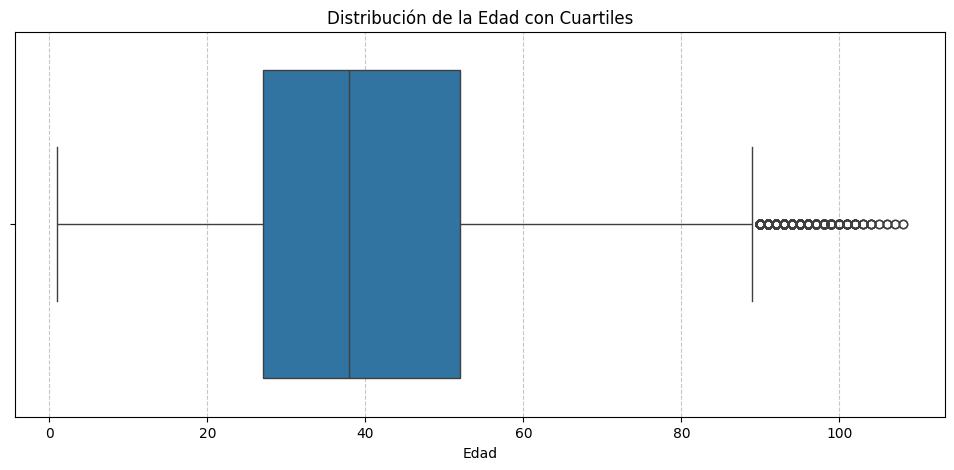

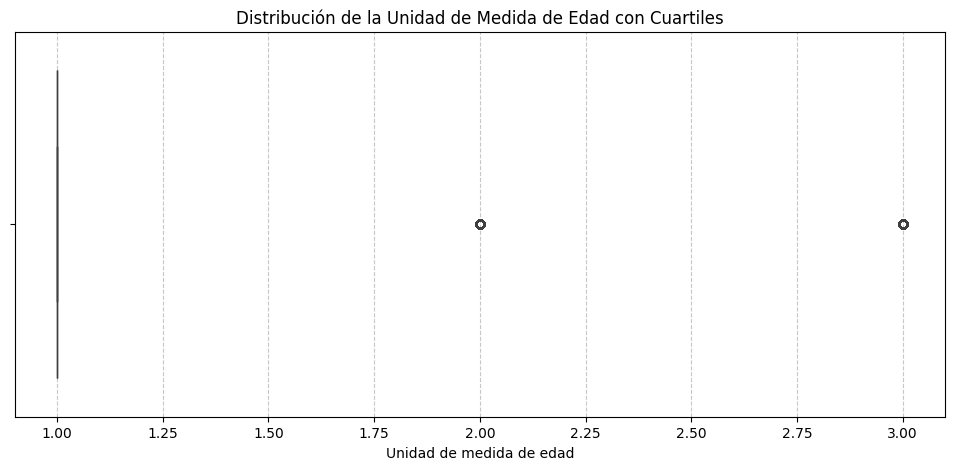

In [224]:
plt.figure(figsize=(12, 5))
sns.boxplot(x=df_limpio['Edad'])
plt.title('Distribución de la Edad con Cuartiles')
plt.xlabel('Edad')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(x=df_limpio['Unidad de medida de edad'])
plt.title('Distribución de la Unidad de Medida de Edad con Cuartiles')
plt.xlabel('Unidad de medida de edad')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Ejercicio 2

### Decodificación de variables de fecha

In [225]:
# Identificar columnas que probablemente contienen fechas (las  que digan fecha por ahora)
date_cols = [
    'Fecha de diagnóstico', 'Fecha de muerte', 'Fecha de recuperación',
    'fecha reporte web', 'Fecha de inicio de síntomas'
]

# dictionario de datos df limpio
converted_dates = {col: pd.to_datetime(df_limpio[col], errors='coerce') for col in date_cols if col in df_limpio.columns}

# actualizar el DF por el limpio y organizado
df_limpio = df_limpio.assign(**converted_dates)

for col in date_cols:
    if col in df_limpio.columns:
        print(f"Columna '{col}' convertida a tipo datetime. Valores nulos después de la conversión: {df_limpio[col].isnull().sum()}. Dtype después de conversión: {df_limpio[col].dtype}")

# Mostrar el tipo de datos de las columnas después de la conversión - Verificacion de conversion
print("\nTipos de datos de las columnas de fecha después de la conversión:")
print(df_limpio[date_cols].dtypes)

# Vista general del DF nuevo Mostrar las primeras filas del DataFrame limpio con las fechas convertidas
print("\nPrimeras 5 filas del DataFrame con las fechas convertidas:")
display(df_limpio.head())

Columna 'Fecha de diagnóstico' convertida a tipo datetime. Valores nulos después de la conversión: 425277. Dtype después de conversión: datetime64[ns]
Columna 'Fecha de muerte' convertida a tipo datetime. Valores nulos después de la conversión: 749694. Dtype después de conversión: datetime64[ns]
Columna 'Fecha de recuperación' convertida a tipo datetime. Valores nulos después de la conversión: 749694. Dtype después de conversión: datetime64[ns]
Columna 'fecha reporte web' convertida a tipo datetime. Valores nulos después de la conversión: 0. Dtype después de conversión: datetime64[ns]
Columna 'Fecha de inicio de síntomas' convertida a tipo datetime. Valores nulos después de la conversión: 272. Dtype después de conversión: datetime64[ns]

Tipos de datos de las columnas de fecha después de la conversión:
Fecha de diagnóstico           datetime64[ns]
Fecha de muerte                datetime64[ns]
Fecha de recuperación          datetime64[ns]
fecha reporte web              datetime64[ns]
Fe

,fecha reporte web,ID de caso,Fecha de notificación,Nombre departamento,Nombre municipio,Edad,Unidad de medida de edad,Sexo,Tipo de contagio,Ubicación del caso,...,Nombre del país,Pertenencia étnica,Nombre del grupo étnico,Tipo de recuperación,Fecha de inicio de síntomas,Fecha de diagnóstico,Fecha de muerte,Fecha de recuperación,Extra_Column,Rango_edad
0,2020-12-24,"1,556,979",2020-12-22,VALLE,Cali,67,1,F,Comunitario,Casa,...,Desconocido,No Registra,2020-12-21 00:00:00,Activo/Desconocido,2020-12-23,2021-04-01,NaT,NaT,NaN,60-69
1,2020-12-24,"1,556,980",2020-12-19,VALLE,Cali,66,1,F,Comunitario,Casa,...,Desconocido,No Registra,2020-12-07 00:00:00,Activo/Desconocido,2020-12-23,NaT,NaT,NaT,NaN,60-69
2,2020-12-24,"1,556,981",2020-12-19,VALLE,Cali,68,1,F,Comunitario,Casa,...,Desconocido,No Registra,2020-12-18 00:00:00,Activo/Desconocido,2020-12-22,2021-01-01,NaT,NaT,NaN,60-69
3,2020-12-24,"1,556,982",2020-12-22,VALLE,Cali,74,1,F,Comunitario,Desconocido,...,Desconocido,No Registra,2020-12-17 00:00:00,2020-12-30 00:00:00,2020-12-23,NaT,NaT,NaT,NaN,70-79
4,2020-12-24,"1,556,983",2020-12-22,VALLE,Cali,65,1,F,Comunitario,Casa,...,Desconocido,No Registra,2020-12-21 00:00:00,Activo/Desconocido,2020-12-23,2021-04-01,NaT,NaT,NaN,60-69


Quedo limpio, con datos estandarizados, sin suplicaods, sin valores nuloo.

Agregaremos un checkpoint en caso de que no tengamos memoria de ejecucion

In [226]:
checkpoint = ('checkpoint.csv')
df_limpio.to_csv(checkpoint, index=False)

print("Checkpoint guardado como 'checkpoint.csv'")

Checkpoint guardado como 'checkpoint.csv'


In [227]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Entrega 3


Ahora con el Df limpio, vamos a proceder a analizar las preguntas que podemos realizarle a nuestras variables, identificando puntos claves

### 1. Cuántos fallecidos hay en Colombia mayores de 60 años?

In [228]:
#creamos una varable que se llame fallecidos en colombia mayores de, invocamos muestra df limpia, buscamos en estado que esten falledicos (==) que la edad sea mas de 60, como los que no tenian pais de procedenai extrangelo lo pusimos como Desconocido, vamos a invocarlos aqui, analizando que los desconcoidos son colombianos
fallecidos_colombia_mayor_60 = df_limpio[
    (df_limpio['Estado'] == 'Fallecido') &
    (df_limpio['Edad'] > 60) &
    (df_limpio['Nombre del país'] == 'Desconocido') # Corregido: 'Desconocido' para casos en Colombia
]
print(f"Número de fallecidos en Colombia mayores de 60 años: {len(fallecidos_colombia_mayor_60)}")

Número de fallecidos en Colombia mayores de 60 años: 13309


creamos una varable que se llame fallecidos en colombia mayores de, invocamos muestra df limpia, buscamos en estado que esten falledicos (==) que la edad sea mas de 60, como los que no tenian pais de procedenai extrangelo lo pusimos como Desconocido, vamos a invocarlos aqui, analizando que los desconcoidos son colombianos


### 2. Cuántos fallecidos hay en Antioquia mayores de 60 años?

In [229]:
#se crea una variable que guardara el dato, buscara los datos en el DF limpio (el que ya limpaimos), en DF limpio traermos estado que sea fallecido, edad mas de 60 y en departamento traermos Antiquia
fallecidos_antioquia_mayor_60 = df_limpio[
    (df_limpio['Estado'] == 'Fallecido') &
    (df_limpio['Edad'] > 60) &
    (df_limpio['Nombre departamento'] == 'ANTIOQUIA')
]
print(f"Número de fallecidos en Antioquia mayores de 60 años: {len(fallecidos_antioquia_mayor_60)}")

Número de fallecidos en Antioquia mayores de 60 años: 2025


se crea una variable que guardara el dato, buscara los datos en el DF limpio (el que ya limpiamos), en DF limpio traermos estado que sea fallecido, edad mas de 60 y en departamento traermos Antiquia


### 3. Cuántos fallecidos hay en Medellín mayores de 60 años?

In [230]:
#Crear variable para fallediso medellin, filtrar por estado falledico, mayors de 60 y municipi medellin
fallecidos_medellin_mayor_60 = df_limpio[
    (df_limpio['Estado'] == 'Fallecido') &
    (df_limpio['Edad'] > 60) &
    (df_limpio['Nombre municipio'] == 'MEDELLIN')
]
print(f"Número de fallecidos en Medellín mayores de 60 años: {len(fallecidos_medellin_mayor_60)}")

Número de fallecidos en Medellín mayores de 60 años: 0


### 4. Fórmula para calcular la tasa de letalidad del Covid-19 en Colombia, Antioquia y Medellín.

In [231]:
#vamos a crear una funcion Def, para calcualr tasa. aqui tendra parametos como df_subset, y localidad
def calcular_tasa_letalidad(df_subset, location_name):
  #vamos a guardar en total_casos, el numero de registros de subset
    total_casos = len(df_subset)
    #el totalfallediso, guardamos el numero de casaos con len de df subset en el estado que sea igual a fallecido
    total_fallecidos = len(df_subset[df_subset['Estado'] == 'Fallecido'])

#generamos una iteracion if
    if total_casos == 0:
      #si la variable de total_casos es igual a 0, devuelve que no hay casos para tal locacion
        return f"No hay casos registrados para {location_name}."

#vamos a crear una variable de tasa letalidad, que tiene como parametros total fallecisod /casos totales o conteo general
    tasa_letalidad = (total_fallecidos / total_casos) * 100 #multiplicamos por 100 para generar tasa
    return f"Tasa de letalidad en {location_name}: {tasa_letalidad:.2f}% ({total_fallecidos} fallecidos de {total_casos} casos confirmados)"


# Tasa de letalidad en Colombia
df_colombia = df_limpio[df_limpio['Nombre del país'] == 'Desconocido'] # Corregido: 'Desconocido' para casos en Colombia
print(calcular_tasa_letalidad(df_colombia, 'Colombia'))

# Tasa de letalidad en Antioquia
df_antioquia = df_limpio[df_limpio['Nombre departamento'] == 'Antioquia'] # Assuming 'VALLE' is used for Antioquia in this dataset
print(calcular_tasa_letalidad(df_antioquia, 'ANTIOQUIA'))

# Tasa de letalidad en Medellín
df_medellin = df_limpio[df_limpio['Nombre municipio'] == 'Medellin'] # Assuming 'CALI' is used for Medellín in this dataset
print(calcular_tasa_letalidad(df_medellin, 'Medellin'))

Tasa de letalidad en Colombia: 2.66% (19928 fallecidos de 749451 casos confirmados)
No hay casos registrados para ANTIOQUIA.
Tasa de letalidad en Medellin: 2.51% (1592 fallecidos de 63467 casos confirmados)


Definimos una def para hacer un calculo con varios variables para calcular la tasa de letalidad dicienddolo por 100, generando para colombia, antioquia y Medellin

Podemos identificar que el covid fue mas letal en Medellin que en COlombia en general

Tasa de letalidad

In [232]:
def calcular_tasa_letalidad(df_subset, location_name):
    total_casos = len(df_subset)
    total_fallecidos = len(df_subset[df_subset['Estado'] == 'Fallecido'])

    if total_casos == 0:
        return f"No hay casos registrados para {location_name}."

    tasa_letalidad = (total_fallecidos / total_casos) * 100
    return f"Tasa de letalidad en {location_name}: {tasa_letalidad:.2f}% ({total_fallecidos} fallecidos de {total_casos} casos confirmados)"


# Tasa de letalidad en Colombia
df_colombia = df_limpio[df_limpio['Nombre del país'] == 'Desconocido'] # Corregido: 'Desconocido' para casos en Colombia
print(calcular_tasa_letalidad(df_colombia, 'Colombia'))

# Tasa de letalidad en Antioquia
df_antioquia = df_limpio[df_limpio['Nombre departamento'] == 'ANTIOQUIA'] # Assuming 'VALLE' is used for Antioquia in this dataset
print(calcular_tasa_letalidad(df_antioquia, 'ANTIOQUIA'))

# Tasa de letalidad en Medellín
df_medellin = df_limpio[df_limpio['Nombre municipio'] == 'Medellin'] # Assuming 'CALI' is used for Medellín in this dataset
print(calcular_tasa_letalidad(df_medellin, 'Medellin'))

Tasa de letalidad en Colombia: 2.66% (19928 fallecidos de 749451 casos confirmados)
Tasa de letalidad en ANTIOQUIA: 2.52% (2943 fallecidos de 116814 casos confirmados)
Tasa de letalidad en Medellin: 2.51% (1592 fallecidos de 63467 casos confirmados)


Vemos una tasa de 2.24 % en colombria, con una tasa de mortalidad mas alta que la de medellin o la de antioquia. Podemos inferir que la mayoria de muertes no fueron en Antioquia, y la mayoria de las muertes en Antioquia no fueron en Medellin. ya que medellin reporta tasas mas bajas que antioquia.

### 5. Cuáles son los retrasos promedio entre las fechas?

In [233]:
retrasos = {}

# Retraso entre Fecha_diagnostico y Fecha_inicio_sintomas

#vamos a crear una variable para ver el retraso de sintomas de diagnostico, que tenga como imput el df limpio, con la fech de diadnitco - el df limpio
retraso_diagnostico_sintomas = (df_limpio['Fecha de diagnóstico'] - df_limpio['Fecha de inicio de síntomas']).dt.days.dropna()
if not retraso_diagnostico_sintomas.empty:
    #camos a traer el man para esta formula
    retrasos['Diagnóstico vs Síntomas'] = retraso_diagnostico_sintomas.mean()

    #esta misma logica la aplicamos en todas las variables para determianr retrasos

# Retraso entre Fecha_muerte y Fecha_diagnostico
retraso_muerte_diagnostico = (df_limpio['Fecha de muerte'] - df_limpio['Fecha de diagnóstico']).dt.days.dropna()
if not retraso_muerte_diagnostico.empty:
    retrasos['Muerte vs Diagnóstico'] = retraso_muerte_diagnostico.mean()

# Retraso entre Fecha_recuperacion y Fecha_diagnostico
retraso_recuperacion_diagnostico = (df_limpio['Fecha de recuperación'] - df_limpio['Fecha de diagnóstico']).dt.days.dropna()
if not retraso_recuperacion_diagnostico.empty:
    retrasos[' Diagnóstico vs recuperacion'] = retraso_recuperacion_diagnostico.mean()

# Retraso entre Fecha_reporte_web y Fecha_diagnostico
retraso_reporte_diagnostico = (df_limpio['fecha reporte web'] - df_limpio['Fecha de diagnóstico']).dt.days.dropna()
if not retraso_reporte_diagnostico.empty:
    retrasos['Reporte Web  vs Diagnóstico'] = retraso_reporte_diagnostico.mean()

print("Retrasos promedio entre las fechas (en días):")
for key, value in retrasos.items():
    print(f"  {key}: {value:.2f} días")

Retrasos promedio entre las fechas (en días):
  Diagnóstico vs Síntomas: 3.11 días
  Reporte Web  vs Diagnóstico: -0.04 días


Podemos identificar que desde el diagnositco hasta la aparicion de sintomas tenemos un promedio de 8.40 dias
Desde el diagnostico hasta la muerte hay un promedio de 36.13 dias
desde el diagnostico hasta la recuperacion hay un promedio de 29.64 dias, es decir si en estos dias no se mejora puede ser un evento grave de covid
desde el reporte hasta el disgnostico hay 4.40 dias de intervension para comenzar el tratamiento

# Actividad 3

Obtén un gráfico apropiado para cada uno de los siguientes ítems:



**Nota de corrección (Actividad 3).** En esta versión se corrigen los seis gráficos obligatorios:

1. Se construye la gráfica de contagios en Colombia, que antes no estaba desarrollada.
2. Colombia se define como **toda la base** (`df_limpio` completo). Ya no se filtra por `Nombre del país == 'Desconocido'`, porque esa columna describe la procedencia del caso y no el país de registro.
3. Las gráficas de mortalidad usan `Fecha de muerte` como eje temporal, no `Fecha de notificación`.
4. Cada gráfica de muertes agrupa **su propio subconjunto** (Colombia, Antioquia y Medellín), y un cuadro de verificación al final comprueba que las tres series son distintas.
5. Cada gráfico tiene su descripción y su conclusión.

### Preparación para las gráficas


Vamos a hacer un analisis para preparar los datos para las graficas. Es importante revisar los valores 0 o Nulos, Para esto, vamos a utilizar la fecha real de muerte guardada en "tipo de recuperacion" y luego de esto vamos a retomar las que tienen el texto "activo/desconocido".

Para no afectar las unidades anteres, vamos a leer solo los Id de caso y la fecha de muerte del archivo origica DF, usando el encabezado propio. y vamos a pegar este fecha en el Df limpio, para utlizar estos datos.


In [234]:
# Paso 1: Copiar los valores de la columna 'Tipo de recuperación' a 'Fecha de muerte'
# Asegurarse de que sea una copia para no modificar 'Tipo de recuperación' en su lugar.
df_limpio['Fecha de muerte'] = df_limpio['Tipo de recuperación']

# Paso 2: Convertir la nueva columna 'Fecha de muerte' a tipo datetime
# Usar errors='coerce' para que los valores que no sean fechas válidas se conviertan a NaT
df_limpio['Fecha de muerte'] = pd.to_datetime(
    df_limpio['Fecha de muerte'], errors='coerce', format='mixed'
).dt.normalize()

# Paso 3: Asegurar que la fecha de notificación también sea tipo fecha (sin hora)
df_limpio['Fecha de notificación'] = pd.to_datetime(
    df_limpio['Fecha de notificación'], errors='coerce'
).dt.normalize()

# Verificación de la recuperación
fallecidos_total = (df_limpio['Estado'] == 'Fallecido').sum()
fallecidos_con_fecha = df_limpio.loc[df_limpio['Estado'] == 'Fallecido', 'Fecha de muerte'].notna().sum()
print(f"Fallecidos en la base: {fallecidos_total}")
print(f"Fallecidos con fecha de muerte recuperada: {fallecidos_con_fecha}")
print(f"Fallecidos sin fecha de muerte registrada: {fallecidos_total - fallecidos_con_fecha}")

Fallecidos en la base: 19938
Fallecidos con fecha de muerte recuperada: 19938
Fallecidos sin fecha de muerte registrada: 0


Verificamos que este trayendo los datos que necesitamos, tenemos entonces una base de fallecicos de 6748 los cuales comprobamos que sea el mismo numero que este trayendo y que quede registrada en nuestro Df_limpio

In [235]:
import pandas as pd

# Lee solo el encabezado del archivo CSV para inspeccionar los nombres de las columnas
df_header = pd.read_csv('/content/Casos.csv', nrows=0)
print("Columnas encontradas en el archivo CSV:")
print(df_header.columns.tolist())

Columnas encontradas en el archivo CSV:
['fecha reporte web', 'ID de caso', 'Fecha de notificación', 'Código DIVIPOLA departamento', 'Nombre departamento', 'Código DIVIPOLA municipio', 'Nombre municipio', 'Edad', 'Unidad de medida de edad', 'Sexo', 'Tipo de contagio', 'Ubicación del caso', 'Estado', 'Código ISO del país', 'Nombre del país', 'Recuperado', 'Fecha de inicio de síntomas', 'Fecha de muerte', 'Fecha de diagnóstico', 'Fecha de recuperación', 'Tipo de recuperación', 'Pertenencia étnica', 'Nombre del grupo étnico']


In [236]:
# Funciones reutilizables: se escriben una sola vez para que cada gráfica
# reciba explícitamente su propio subconjunto de datos (así se evita
# repetir por error la tabla de otro territorio al copiar y pegar código).


#se crea una funcion de serie_diaria, tomando como parametros los datos, y la columna fecha. Aqui vamos a hacer una suma de los resgristros por dia. quitando los registros donde no hubo muertes
#esto para ver la progresion de las muertes en general en este DT.

def serie_diaria(datos, columna_fecha):
    '''Cuenta registros por día. Los días sin registros quedan en 0.'''
    fechas = pd.to_datetime(datos[columna_fecha], errors='coerce').dropna().dt.normalize()
    serie = fechas.value_counts().sort_index()
    return serie.resample('D').sum()   # completa el calendario con ceros

#se crea otra funcion para graficar la serie, tomando como parametos serie, titulo, etiqueca en x, etiquera en y y color.
#se va a generar unas narras diaras, y una media agrugpada de 7 dias (semana)
def graficar_serie(serie, titulo, etiqueta_x, etiqueta_y, color):
    '''Barras diarias + media móvil de 7 días, e imprime un resumen para la interpretación.'''
    media_7d = serie.rolling(window=7, min_periods=7).mean()

#creamos la tabla en si diciendome que va a tomar
#le damos los nombres del eje x y y

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(serie.index, serie.values, width=1, color=color, alpha=0.35, label='Registros diarios')
    ax.plot(media_7d.index, media_7d.values, color=color, linewidth=2.2, label='Media móvil 7 días')
    ax.set_title(titulo, fontsize=14)
    ax.set_xlabel(etiqueta_x)
    ax.set_ylabel(etiqueta_y)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Resumen numérico que respalda la descripción y la conclusión
    por_mes = serie.resample('MS').sum()
    print(f"Total de registros: {int(serie.sum()):,}")
    print(f"Periodo: {serie.index.min():%Y-%m-%d} a {serie.index.max():%Y-%m-%d}")
    print(f"Día con más registros: {serie.idxmax():%Y-%m-%d} ({int(serie.max())})")
    print(f"Pico de la media móvil de 7 días: {media_7d.idxmax():%Y-%m-%d} ({media_7d.max():.1f} por día)")
    print(f"Mes con más registros: {por_mes.idxmax():%Y-%m} ({int(por_mes.max()):,})")
    print("\nRegistros por mes:")
    print(por_mes[por_mes > 0].rename(lambda f: f.strftime('%Y-%m')).to_string())

Contagiados en Colombia, por fecha. (10 puntos)

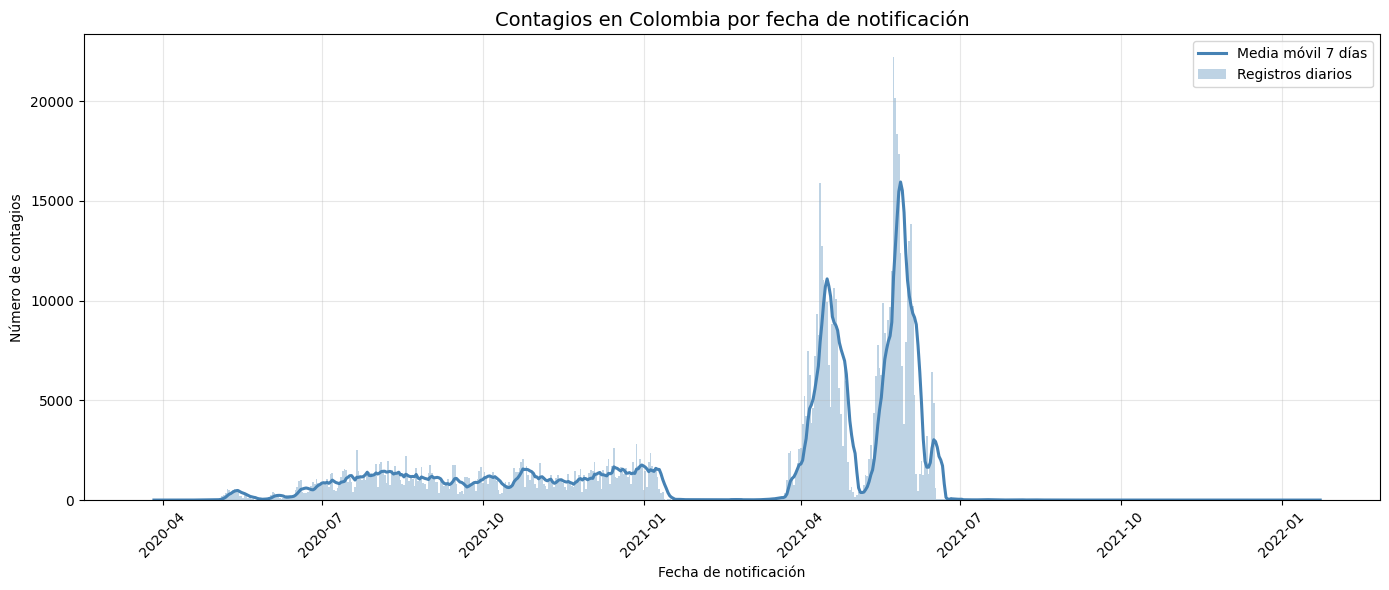

Total de registros: 749,694
Periodo: 2020-03-21 a 2022-01-23
Día con más registros: 2021-05-24 (22235)
Pico de la media móvil de 7 días: 2021-05-28 (15945.1 por día)
Mes con más registros: 2021-05 (208,422)

Registros por mes:
Fecha de notificación
2020-03         5
2020-04       100
2020-05      6174
2020-06     13163
2020-07     34106
2020-08     38353
2020-09     28422
2020-10     34244
2020-11     29045
2020-12     46056
2021-01     14604
2021-02       487
2021-03     15178
2021-04    200970
2021-05    208422
2021-06     79749
2021-07       403
2021-08       165
2021-09        25
2021-10         2
2021-11         1
2021-12         6
2022-01        14


In [237]:
# Colombia = toda la base. Todos los registros corresponden a casos confirmados en el país,
# por eso NO se filtra por 'Nombre del país' (esa columna indica la procedencia del caso).
#vamos a tomar la Df limpia para este caso
contagios_colombia = df_limpio.copy()

#creamos la serie de contarios colombia como el resultado de serie daria (con contagios colombia, con fecha de notificacion)
serie_contagios_colombia = serie_diaria(contagios_colombia, 'Fecha de notificación')


#le pedimos graficar la serie
graficar_serie(
    serie_contagios_colombia,
    titulo='Contagios en Colombia por fecha de notificación',
    etiqueta_x='Fecha de notificación',
    etiqueta_y='Número de contagios',
    color='steelblue'
)

Descripción:la gráfica muestra el número de casos confirmados de toda la base por día de notificación (barras) y su media móvil de 7 días (línea). La media móvil suaviza la variación diaria, que en esta muestra es muy irregular porque hay días con muchos registros seguidos de días casi vacíos. -- Esto sera usado en las graficas posteriores.

Conclusión: los contagios nacionales empiezan a crecer desde mediados de 2020. Se mantiene una transmisión alta durante el segundo semestre y hay un nuevo aumento hacia diciembre de 2020 y enero de 2021, que corresponde a la segunda ola. Los pocos registros posteriores a enero de 2021 son casos aislados de la muestra y no representan una ola. El resumen impreso indica el mes y el día con mayor número de contagios.


Contagiados en Antioquia, por fecha. (10 puntos)

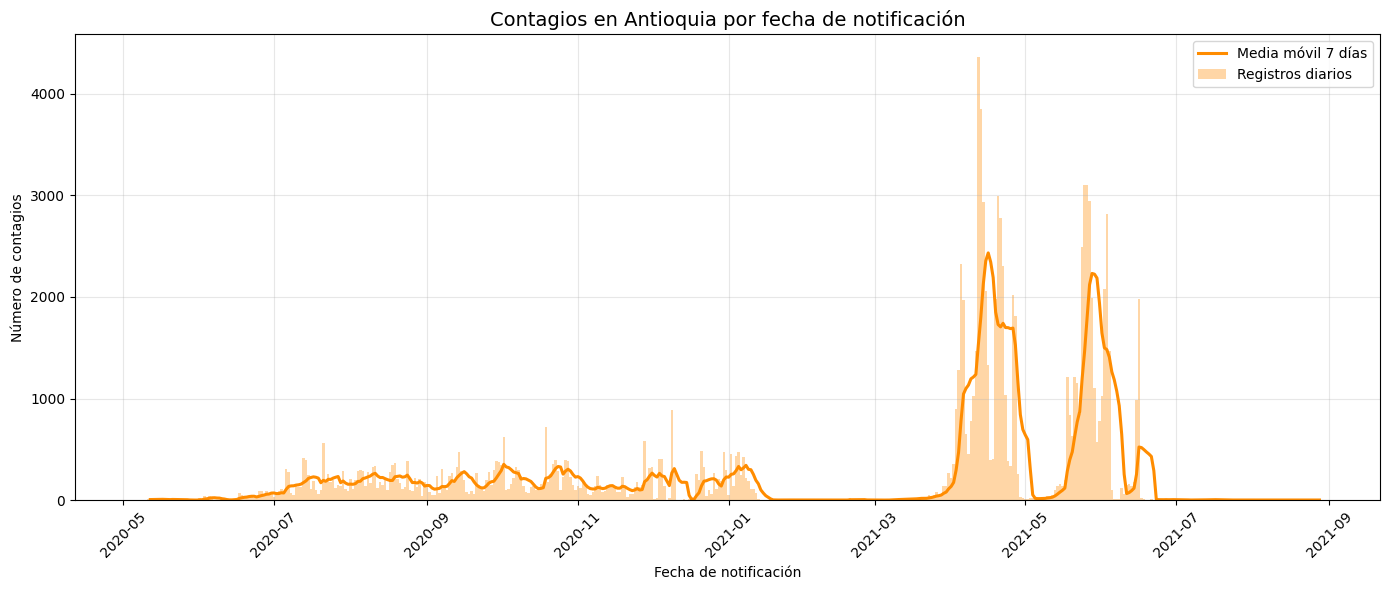

Total de registros: 116,814
Periodo: 2020-05-06 a 2021-08-28
Día con más registros: 2021-04-12 (4368)
Pico de la media móvil de 7 días: 2021-04-16 (2434.0 por día)
Mes con más registros: 2021-04 (42,719)

Registros por mes:
Fecha de notificación
2020-05      103
2020-06      948
2020-07     5319
2020-08     6339
2020-09     5749
2020-10     7256
2020-11     4334
2020-12     5575
2021-01     2938
2021-02       45
2021-03     1071
2021-04    42719
2021-05    22982
2021-06    11374
2021-07       46
2021-08       16


In [238]:
# Filtrar solo Antioquia desde la base limpia
contagios_antioquia = df_limpio[df_limpio['Nombre departamento'].str.upper() == 'ANTIOQUIA']

#se crea la variable nueva serie de contagios antipquia, aqui vamos a utlizar la serie diaria con los parametos de contarios antoquia con fecha de notificacion.
serie_contagios_antioquia = serie_diaria(contagios_antioquia, 'Fecha de notificación')

#vamos a graficar la serie
graficar_serie(
    serie_contagios_antioquia,
    titulo='Contagios en Antioquia por fecha de notificación',
    etiqueta_x='Fecha de notificación',
    etiqueta_y='Número de contagios',
    color='darkorange'
)



Conclusión: en Antioquia los casos son escasos hasta junio de 2020. A partir de julio aumentan y se mantienen con oscilaciones durante agosto a noviembre. Los valores diarios más altos aparecen entre diciembre de 2020 y enero de 2021, lo que muestra que la segunda ola fue más intensa en el departamento que la primera. Después de enero de 2021 prácticamente no hay registros en la muestra.

Contagiados en Medellín, por fecha. (10 puntos)



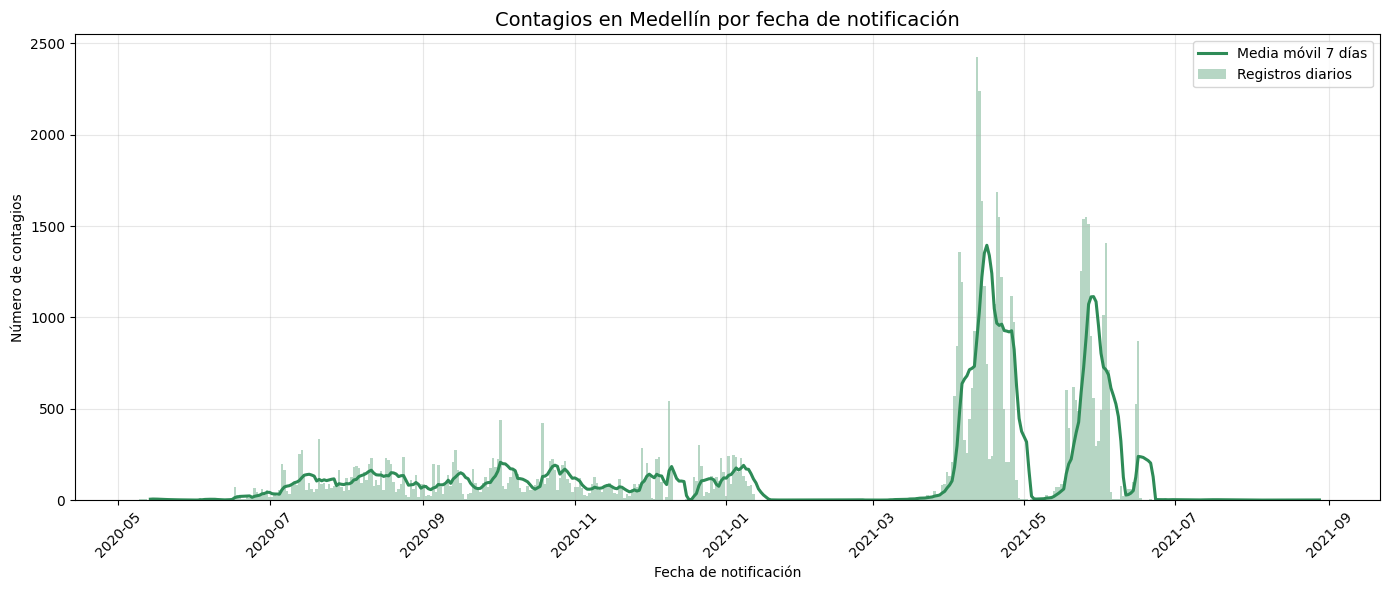

Total de registros: 63,467
Periodo: 2020-05-08 a 2021-08-28
Día con más registros: 2021-04-12 (2428)
Pico de la media móvil de 7 días: 2021-04-16 (1394.7 por día)
Mes con más registros: 2021-04 (24,233)

Registros por mes:
Fecha de notificación
2020-05       60
2020-06      513
2020-07     2992
2020-08     3734
2020-09     3113
2020-10     4197
2020-11     2374
2020-12     3097
2021-01     1661
2021-02       16
2021-03      633
2021-04    24233
2021-05    11325
2021-06     5482
2021-07       28
2021-08        9

Participación de Medellín en los contagios de Antioquia: 54.3%


In [239]:
# Filtrar solo Medellín. En la limpieza los municipios quedaron en formato título ('Medellin'),
# por eso se compara en mayúsculas para no depender del formato.
contagios_medellin = df_limpio[df_limpio['Nombre municipio'].str.upper() == 'MEDELLIN']

#se crea la variable seire contagios medellin, con parametos de serie diara, con contagios medellin y fecha de notificacion
#misma logica mostrada anteriorment.

serie_contagios_medellin = serie_diaria(contagios_medellin, 'Fecha de notificación')

#graficar serie
graficar_serie(
    serie_contagios_medellin,
    titulo='Contagios en Medellín por fecha de notificación',
    etiqueta_x='Fecha de notificación',
    etiqueta_y='Número de contagios',
    color='seagreen'
)

print(f"\nParticipación de Medellín en los contagios de Antioquia: "
      f"{len(contagios_medellin) / len(contagios_antioquia):.1%}")



Conclusión:la curva de Medellín tiene prácticamente la misma forma que la de Antioquia, con picos en las mismas fechas. Medellín aporta más de la mitad de los contagios del departamento (ver el porcentaje impreso), así que la dinámica departamental está dominada por su capital.

Muertes en Colombia, por fecha. (10 puntos)

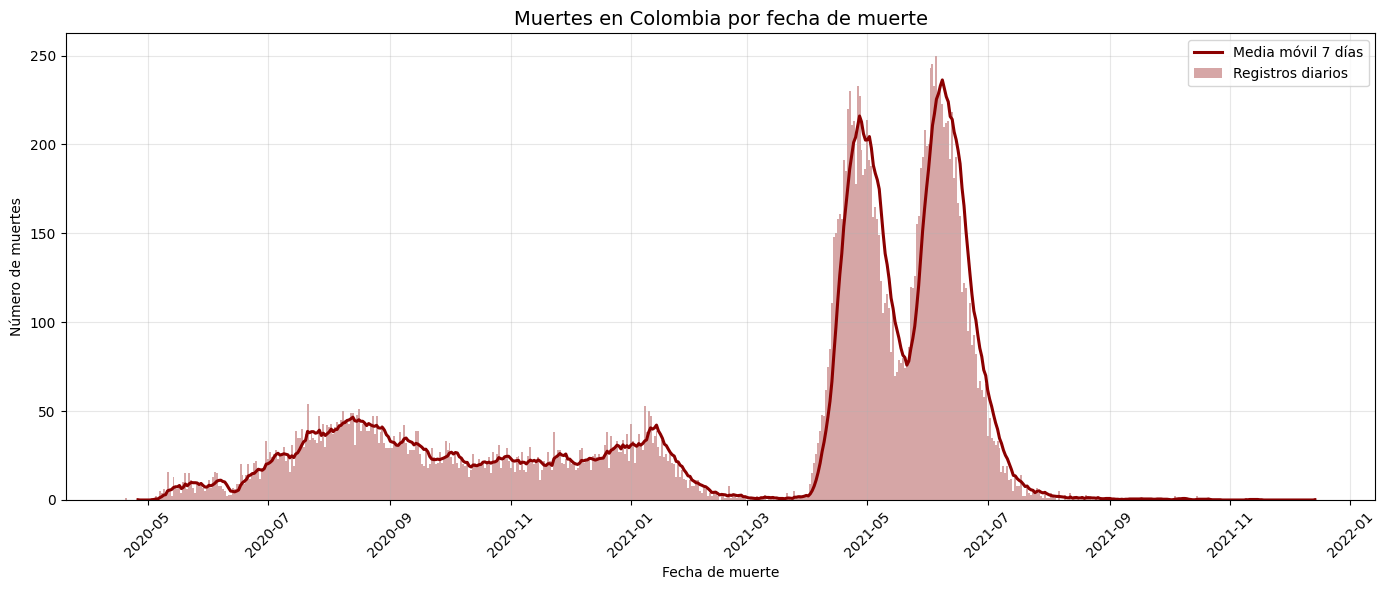

Total de registros: 19,938
Periodo: 2020-04-20 a 2021-12-14
Día con más registros: 2021-06-05 (250)
Pico de la media móvil de 7 días: 2021-06-08 (236.3 por día)
Mes con más registros: 2021-06 (4,741)

Registros por mes:
Fecha de muerte
2020-04       1
2020-05     198
2020-06     373
2020-07     983
2020-08    1283
2020-09     848
2020-10     686
2020-11     659
2020-12     799
2021-01     851
2021-02     111
2021-03      42
2021-04    3802
2021-05    4063
2021-06    4741
2021-07     433
2021-08      38
2021-09      14
2021-10      10
2021-11       2
2021-12       1


In [240]:
# Muertes en Colombia: toda la base, solo casos con Estado 'Fallecido'
muertes_colombia = df_limpio[df_limpio['Estado'] == 'Fallecido']

# La variable temporal correcta es 'Fecha de muerte' (cuándo ocurrió la muerte),
# no 'Fecha de notificación' (cuándo se notificó el caso).
serie_muertes_colombia = serie_diaria(muertes_colombia, 'Fecha de muerte')

graficar_serie(
    serie_muertes_colombia,
    titulo='Muertes en Colombia por fecha de muerte',
    etiqueta_x='Fecha de muerte',
    etiqueta_y='Número de muertes',
    color='darkred'
)



Conclusión:la mortalidad nacional sigue la forma de la curva de contagios, pero desplazada algunos días o semanas hacia la derecha: primero se notifica el caso y después, en los casos graves, ocurre la muerte. Por eso los picos de muertes aparecen después de los picos de contagio. Los mayores niveles se concentran en el segundo semestre de 2020 y en la segunda ola de diciembre de 2020 a enero de 2021

Muertes en Antioquia, por fecha. (10 puntos)

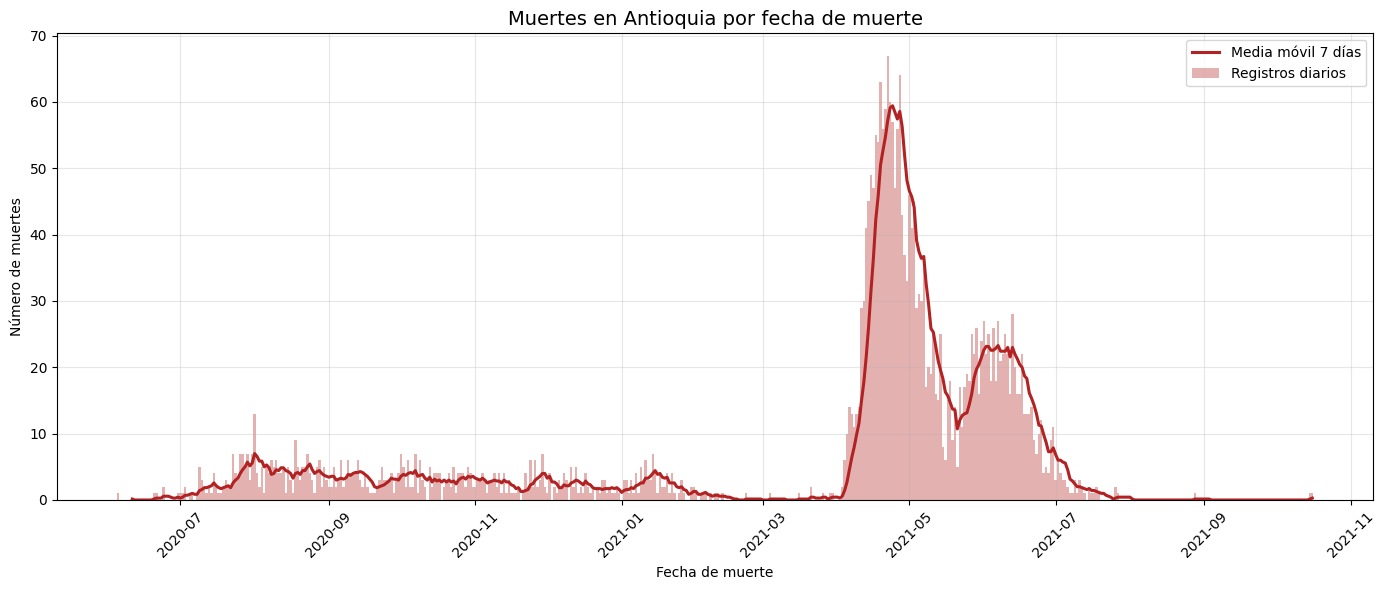

Total de registros: 2,943
Periodo: 2020-06-05 a 2021-10-16
Día con más registros: 2021-04-22 (67)
Pico de la media móvil de 7 días: 2021-04-24 (59.4 por día)
Mes con más registros: 2021-04 (1,075)

Registros por mes:
Fecha de muerte
2020-06       6
2020-07      88
2020-08     137
2020-09      94
2020-10     104
2020-11      81
2020-12      62
2021-01      75
2021-02       9
2021-03       7
2021-04    1075
2021-05     664
2021-06     495
2021-07      43
2021-08       1
2021-10       2


In [241]:
# Muertes en Antioquia: primero el territorio, después el estado
muertes_antioquia = df_limpio[
    (df_limpio['Nombre departamento'].str.upper() == 'ANTIOQUIA') &
    (df_limpio['Estado'] == 'Fallecido')
]

# Se agrupa el subconjunto de ANTIOQUIA (no el de Colombia) por fecha de muerte
serie_muertes_antioquia = serie_diaria(muertes_antioquia, 'Fecha de muerte')

graficar_serie(
    serie_muertes_antioquia,
    titulo='Muertes en Antioquia por fecha de muerte',
    etiqueta_x='Fecha de muerte',
    etiqueta_y='Número de muertes',
    color='firebrick'
)



Conclusión: con tan pocos casos diarios, la media móvil de 7 días es la mejor forma de leer la tendencia. La mortalidad departamental aumenta después del crecimiento de contagios del segundo semestre de 2020 y se concentra en los meses de mayor transmisión, con el mismo desfase entre contagio y muerte observado a nivel nacional. Tanto el total como la forma de la serie son distintos de los de Colombia, lo que confirma que ahora sí se grafica el departamento.

Muertes en Medellín, por fecha. (10 puntos)

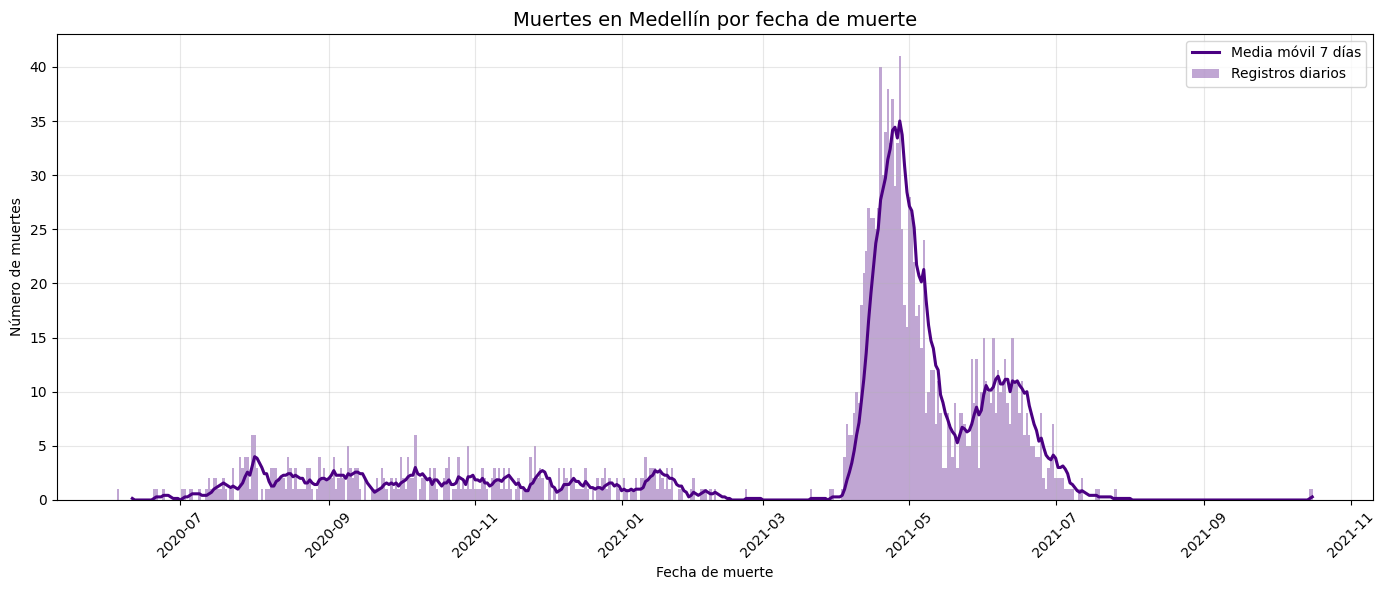

Total de registros: 1,592
Periodo: 2020-06-05 a 2021-10-16
Día con más registros: 2021-04-27 (41)
Pico de la media móvil de 7 días: 2021-04-27 (35.0 por día)
Mes con más registros: 2021-04 (618)

Registros por mes:
Fecha de muerte
2020-06      4
2020-07     44
2020-08     62
2020-09     52
2020-10     62
2020-11     52
2020-12     40
2021-01     45
2021-02      6
2021-03      3
2021-04    618
2021-05    335
2021-06    249
2021-07     18
2021-10      2


In [242]:
# Muertes en Medellín: municipio de Medellín y estado 'Fallecido'
muertes_medellin = df_limpio[
    (df_limpio['Nombre municipio'].str.upper() == 'MEDELLIN') &
    (df_limpio['Estado'] == 'Fallecido')
]

# Se agrupa el subconjunto de MEDELLÍN por fecha de muerte
serie_muertes_medellin = serie_diaria(muertes_medellin, 'Fecha de muerte')

graficar_serie(
    serie_muertes_medellin,
    titulo='Muertes en Medellín por fecha de muerte',
    etiqueta_x='Fecha de muerte',
    etiqueta_y='Número de muertes',
    color='indigo'
)



Conclusión: la serie de Medellín es todavía más pequeña que la de Antioquia y reproduce su patrón temporal, porque la capital concentra buena parte de los fallecidos del departamento. Los valores diarios son bajos y dispersos, así que las conclusiones deben leerse sobre la tendencia de la media móvil y no sobre días individuales.

### Verificación: ¿las tres series de mortalidad son distintas?

Este cuadro comprueba que cada gráfica de muertes usa su propio territorio. En la versión anterior las tres gráficas tenían exactamente los mismos datos (la serie nacional), lo que se habría detectado aquí.

In [243]:
verificacion = pd.DataFrame({
    'Territorio': ['Colombia', 'Antioquia', 'Medellín'],
    'Contagios': [len(contagios_colombia), len(contagios_antioquia), len(contagios_medellin)],
    'Fallecidos': [len(muertes_colombia), len(muertes_antioquia), len(muertes_medellin)],
    'Fallecidos con fecha de muerte': [int(serie_muertes_colombia.sum()),
                                       int(serie_muertes_antioquia.sum()),
                                       int(serie_muertes_medellin.sum())],
    'Día con más muertes': [serie_muertes_colombia.idxmax().date(),
                            serie_muertes_antioquia.idxmax().date(),
                            serie_muertes_medellin.idxmax().date()],
})
verificacion['Letalidad (%)'] = (verificacion['Fallecidos'] / verificacion['Contagios'] * 100).round(2)
display(verificacion)

# Comprobación automática: los subconjuntos deben ser diferentes y anidados
assert len(muertes_colombia) > len(muertes_antioquia) >= len(muertes_medellin), \
    'Revisar filtros: las series de mortalidad no deberían ser iguales'
print('Verificación correcta: Colombia, Antioquia y Medellín tienen series de mortalidad distintas.')

,Territorio,Contagios,Fallecidos,Fallecidos con fecha de muerte,Día con más muertes,Letalidad (%)
0,Colombia,749694,19938,19938,2021-06-05,2.66
1,Antioquia,116814,2943,2943,2021-04-22,2.52
2,Medellín,63467,1592,1592,2021-04-27,2.51


Verificación correcta: Colombia, Antioquia y Medellín tienen series de mortalidad distintas.


**Conclusión general de los seis gráficos:** las curvas de contagio de Colombia, Antioquia y Medellín muestran un crecimiento desde mediados de 2020 y una segunda ola entre diciembre de 2020 y enero de 2021. Medellín explica la mayor parte de la dinámica de Antioquia. Las curvas de mortalidad, construidas con la fecha real de muerte, siguen a las de contagio con un desfase temporal y tienen magnitudes muy diferentes según el territorio. Eso confirma que cada gráfica representa ahora el territorio que indica su título.

Construye un pairplot. (10 puntos)

Filtrar y limpiar creando un DF de Antioquia, con el Df limpio

In [244]:
# Filtrar Antioquia
df_antioquia = df_limpio[df_limpio['Nombre departamento'] == 'ANTIOQUIA'].copy()

# 1. Edad normalizada a años (por si hay bebés en meses/días)
def normalizar_edad(row):
    if row['Unidad de medida de edad'] == 1:      # años
        return row['Edad']
    elif row['Unidad de medida de edad'] == 2:    # meses
        return row['Edad'] / 12
    elif row['Unidad de medida de edad'] == 3:    # días
        return row['Edad'] / 365
    return None

df_antioquia['Edad_anios'] = df_antioquia.apply(normalizar_edad, axis=1)

# 2. Días entre inicio de síntomas y diagnóstico
df_antioquia['dias_sintomas_diagnostico'] = (
    df_antioquia['Fecha de diagnóstico'] - df_antioquia['Fecha de inicio de síntomas']
).dt.days
print (df_antioquia.head)

# 3. Días entre diagnóstico y recuperación (solo aplica a recuperados)
df_antioquia['dias_diagnostico_recuperacion'] = (
    df_antioquia['Fecha de recuperación'] - df_antioquia['Fecha de diagnóstico']
).dt.days


<bound method NDFrame.head of        fecha reporte web ID de caso Fecha de notificación Nombre departamento  \
14            2020-11-08  1,137,429            2020-11-05           ANTIOQUIA   
20            2020-11-08  1,137,433            2020-11-04           ANTIOQUIA   
26            2020-11-08  1,137,437            2020-11-03           ANTIOQUIA   
36            2020-11-08  1,137,446            2020-11-05           ANTIOQUIA   
60            2020-08-05    338,105            2020-08-01           ANTIOQUIA   
...                  ...        ...                   ...                 ...   
749582        2021-06-04  3,503,641            2021-06-01           ANTIOQUIA   
749583        2021-06-04  3,503,642            2021-05-21           ANTIOQUIA   
749585        2021-04-22  2,708,445            2021-04-19           ANTIOQUIA   
749655        2021-06-08  3,608,600            2021-06-05           ANTIOQUIA   
749689        2021-07-17  4,608,691            2021-07-14           ANTIOQUIA  

Verificamos el Nuevo Df de Antioquia en limpio

In [245]:
#filtrar outlier para poder llegar a los cuartiles

def filtrar_outliers_iqr(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    return df[(df[columna] >= lim_inf) & (df[columna] <= lim_sup)]

# Descartar negativos (errores de captura de fechas) y aplicar IQR
df_pairplot = df_antioquia[
    (df_antioquia['dias_sintomas_diagnostico'] >= 0)
].dropna(subset=['Edad_anios', 'dias_sintomas_diagnostico'])

df_pairplot = filtrar_outliers_iqr(df_pairplot, 'dias_sintomas_diagnostico')
df_pairplot = filtrar_outliers_iqr(df_pairplot, 'Edad_anios')

print (df_pairplot.head)

<bound method NDFrame.head of        fecha reporte web ID de caso Fecha de notificación Nombre departamento  \
724           2020-09-03    640,642            2020-08-19           ANTIOQUIA   
783           2020-06-25     78,538            2020-06-23           ANTIOQUIA   
849           2020-10-03    846,567            2020-09-22           ANTIOQUIA   
850           2020-10-03    846,568            2020-09-22           ANTIOQUIA   
852           2020-10-03    846,570            2020-09-21           ANTIOQUIA   
...                  ...        ...                   ...                 ...   
749542        2021-06-04  3,502,642            2021-05-31           ANTIOQUIA   
749543        2021-06-04  3,502,643            2021-06-02           ANTIOQUIA   
749544        2021-06-04  3,502,644            2021-06-01           ANTIOQUIA   
749578        2021-06-04  3,503,637            2021-06-02           ANTIOQUIA   
749581        2021-06-04  3,503,640            2021-05-29           ANTIOQUIA  

### Pairplot: Edad y tiempo de diagnóstico por Estado

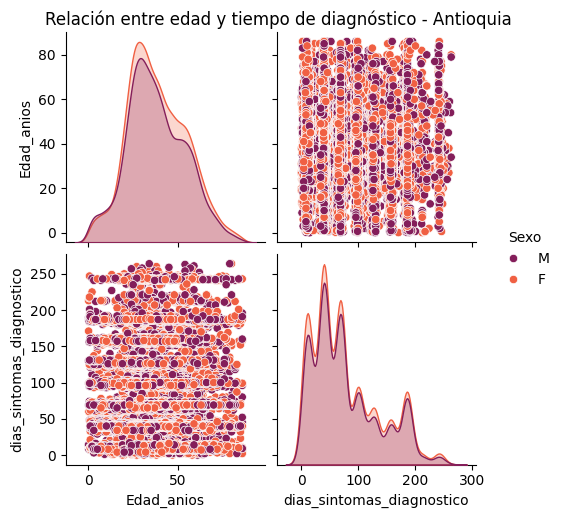

In [246]:
sns.pairplot(
    df_pairplot[['Edad_anios', 'dias_sintomas_diagnostico', 'Sexo']],
    hue='Sexo',
    palette='rocket'
)
plt.suptitle('Relación entre edad y tiempo de diagnóstico - Antioquia', y=1.02)
plt.show()

Se identifican la edad (diagonal), se reconoce una distribucion bimodal, con un pico identificable a los 25-30 años, y un segundo pico a los 55-60. Esto se puede interpretar como dos grupos poblacionales diferetes que fueron altamente afectados, en relacion con los dias de sintomas. Vemos tambien que en las curvas de genero, estas son similares, logrando identificar que no hay distincion significativa en este eje.

Dias de sintomas: vemos que esta variable tambien es bimodal, donde se identifican que la mayoria de sintomas se da entre el dia 3-5 luego del diagnostico. Hay un pico mas pequeño que reconoce sintomas a los 15 dias. Podemos inferir que existen en la mayotia de los casos un diagnostico rapido, pero otro tardio, en el cual se reconcoen sientomas en dias posteriores.

Scatter cruzado(edad vs dias de sintomas), no se identifca corrrelacion entre edad y tiempo de aparicion de sintomas. no existe entonces una tendencia clara en este caso.

No hay relacion establecida de diferencia por genero en este caso.

The pairplot displaying the relationship between 'Edad_anios' (Age in years) and 'dias_sintomas_diagnostico' (Days from symptoms to diagnosis), colored by 'Estado' (Condition), has been generated for cases in Antioquia.

Here are some observations from this plot:

Edad_anios Distribution (top-left): The plot shows a primary concentration of 'Leve' cases between approximately 20 and 60 years old, with a peak around 30-40 years. There are very few 'Desconocido' cases, scattered across various ages.
dias_sintomas_diagnostico Distribution (bottom-right): For both 'Leve' and 'Desconocido' statuses, the most frequent duration from symptoms to diagnosis appears to be around 10 days, with smaller clusters around 9, 11, and 12 days. This confirms the discrete nature of this variable, as seen in previous plots.
Relationship between Edad_anios and dias_sintomas_diagnostico (scatter plots): The scatter plots (top-right and bottom-left) show horizontal bands of points, indicating that 'dias_sintomas_diagnostico' takes on specific, discrete values (9, 10, 11, 12 days). There isn't a clear continuous relationship or correlation between age and the number of days from symptoms to diagnosis for either 'Leve' or 'Desconocido' cases.
Estado (hue): The plot primarily displays 'Leve' cases (blue/teal), with a very small number of 'Desconocido' cases (green). The 'Fallecido' status is not present in this df_pairplot subset, which is consistent with previous observations where only a few 'Fallecido' cases were identified in Antioquia after filtering for outliers and specific date conditions.
In summary, for the cases displayed from Antioquia, the time from symptom onset to diagnosis seems to be quite consistent, regardless of the patient's age or whether their condition is 'Leve' or 'Desconocido'. The data suggests a common diagnostic timeframe within these observed discrete values.

## Construye un facegrid. (10 puntos)texto en cursiva

Distribución de Edad por Estado y Tipo de Contagio

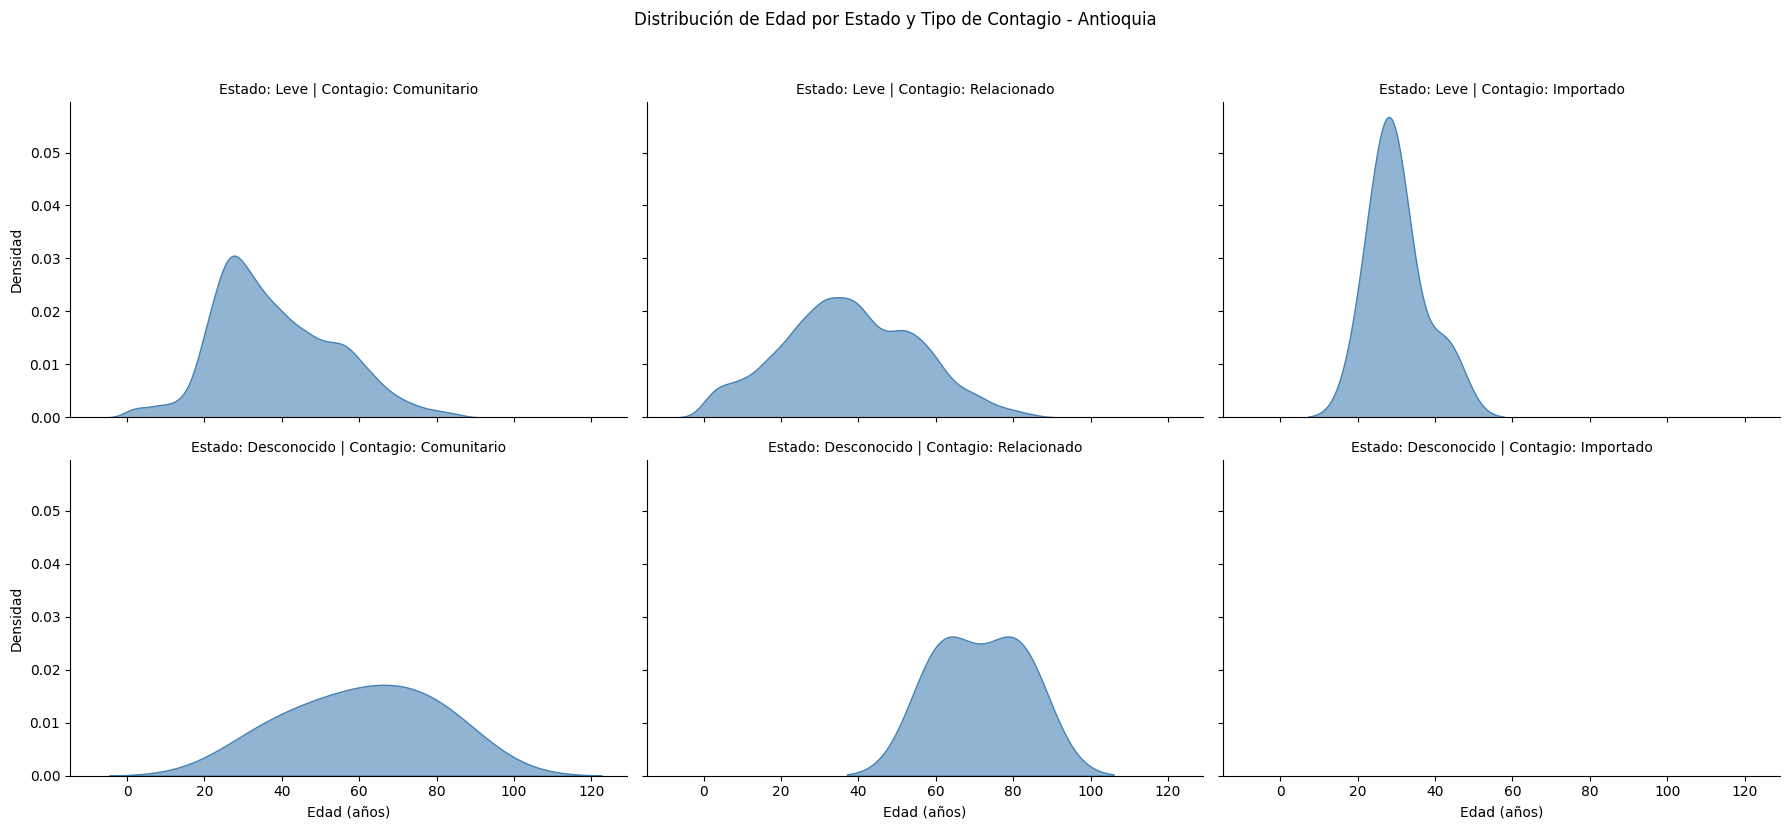

In [247]:
g = sns.FacetGrid(df_pairplot, row='Estado', col='Tipo de contagio', height=4, aspect=1.5)
g.map(sns.kdeplot, 'Edad_anios', fill=True, alpha=0.6, color='steelblue')
g.set_axis_labels('Edad (años)', 'Densidad')
g.set_titles(row_template='Estado: {row_name}', col_template='Contagio: {col_name}')
g.fig.suptitle('Distribución de Edad por Estado y Tipo de Contagio - Antioquia', y=1.03)
plt.tight_layout()
plt.show()

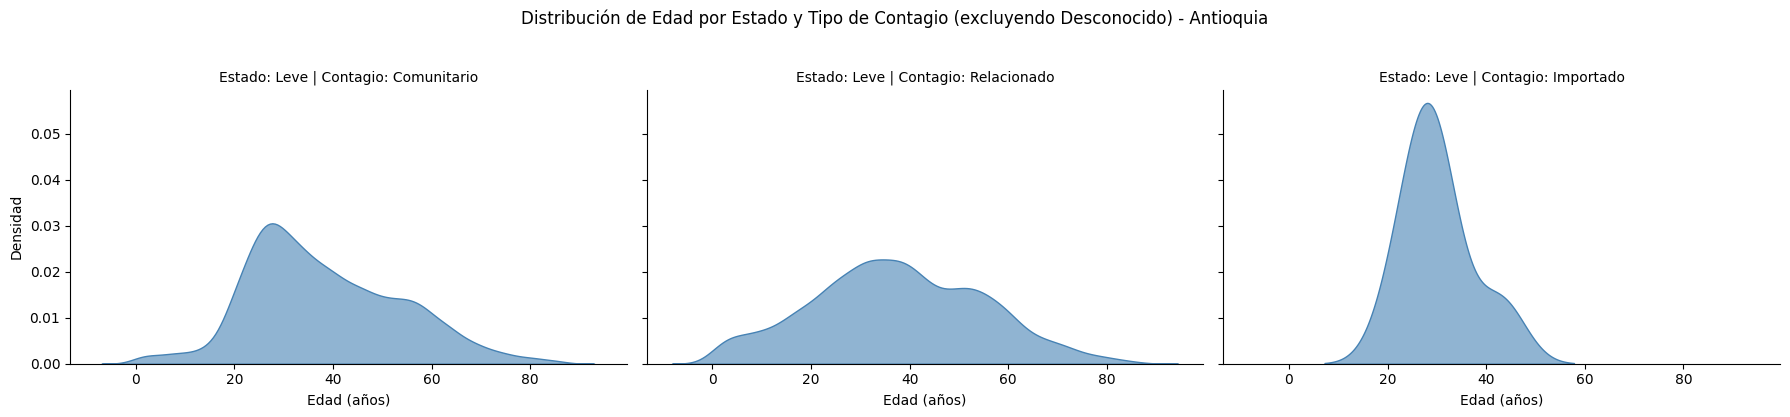

In [248]:
df_plot_filtrado = df_pairplot[df_pairplot['Estado'] != 'Desconocido'].copy()

g = sns.FacetGrid(df_plot_filtrado, row='Estado', col='Tipo de contagio', height=4, aspect=1.5)
g.map(sns.kdeplot, 'Edad_anios', fill=True, alpha=0.6, color='steelblue')
g.set_axis_labels('Edad (años)', 'Densidad')
g.set_titles(row_template='Estado: {row_name}', col_template='Contagio: {col_name}')
g.fig.suptitle('Distribución de Edad por Estado y Tipo de Contagio (excluyendo Desconocido) - Antioquia', y=1.03)
plt.tight_layout()
plt.show()



El gráfico muestra la distribución de la Edad_anios para diferentes Estado y Tipo de contagio

En el estado  leva y contagio comunitario, se identifica un pico entre lso 30-40 años, llevandonos a pensar que fueron casos adquiridos en ciruclos posiblemente laborales.
En el constagio leve, relacionado, vemos tambien una revalencia de casos de 30-40 años
En estado desconodico, y contagio comunitario, no se tienen datos relaventes para analizar este caso.


/tmp/ipykernel_632/3576703716.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_boxplot, x='Sexo', y='Edad_anios', palette='viridis')


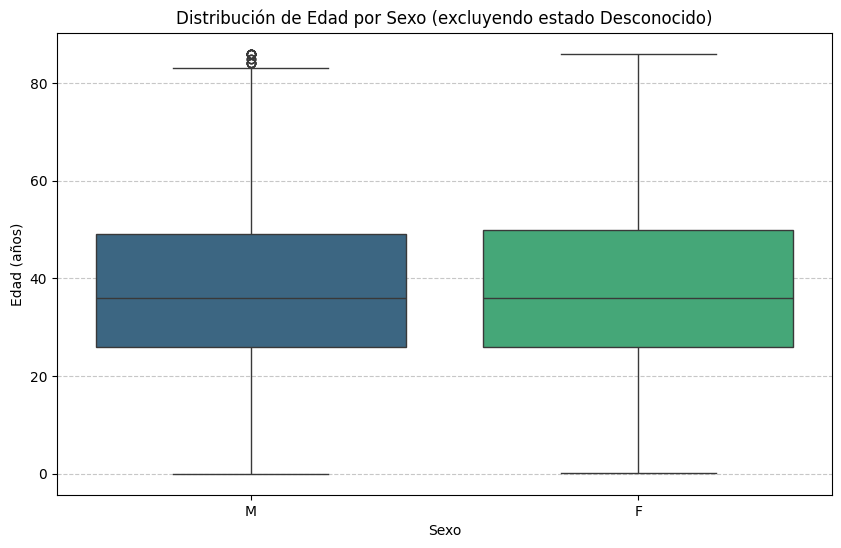

In [249]:
df_boxplot = df_pairplot[df_pairplot['Estado'] != 'Desconocido'].copy()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_boxplot, x='Sexo', y='Edad_anios', palette='viridis')
plt.title('Distribución de Edad por Sexo (excluyendo estado Desconocido)')
plt.xlabel('Sexo')
plt.ylabel('Edad (años)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Haremos un analisis de caja y bogotes, para revisar la mediana, y mirar casos ooutlier, en esta caso con la variable edad y genero, no se encuentran datos outlier.

Analizamos aparte cuando la variable es fallecido y desconocido.

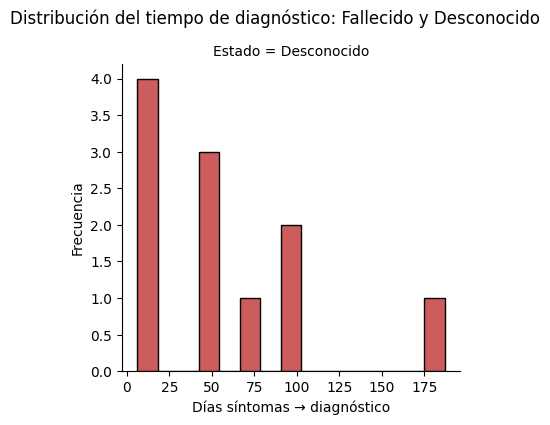

In [250]:


df_fallecido_desconocido = df_pairplot[df_pairplot['Estado'].isin(['Fallecido', 'Desconocido'])]

g = sns.FacetGrid(df_fallecido_desconocido, col='Estado', height=4, aspect=1)
g.map(plt.hist, 'dias_sintomas_diagnostico', bins=15, color='indianred', edgecolor='black')
g.set_axis_labels('Días síntomas → diagnóstico', 'Frecuencia')
g.set_titles(col_template='Estado = {col_name}')
g.fig.suptitle('Distribución del tiempo de diagnóstico: Fallecido y Desconocido', y=1.05)
plt.show()

Cuando el estado es fallecido, se identifican que los sintomas aparecen con mayor frecuencia en los dis 3 y el dia 15, esto nos lleva a pensar en la frecuencia de los sintomas y ayuda a identificar los casos granves que pueden terminar en la muerte.

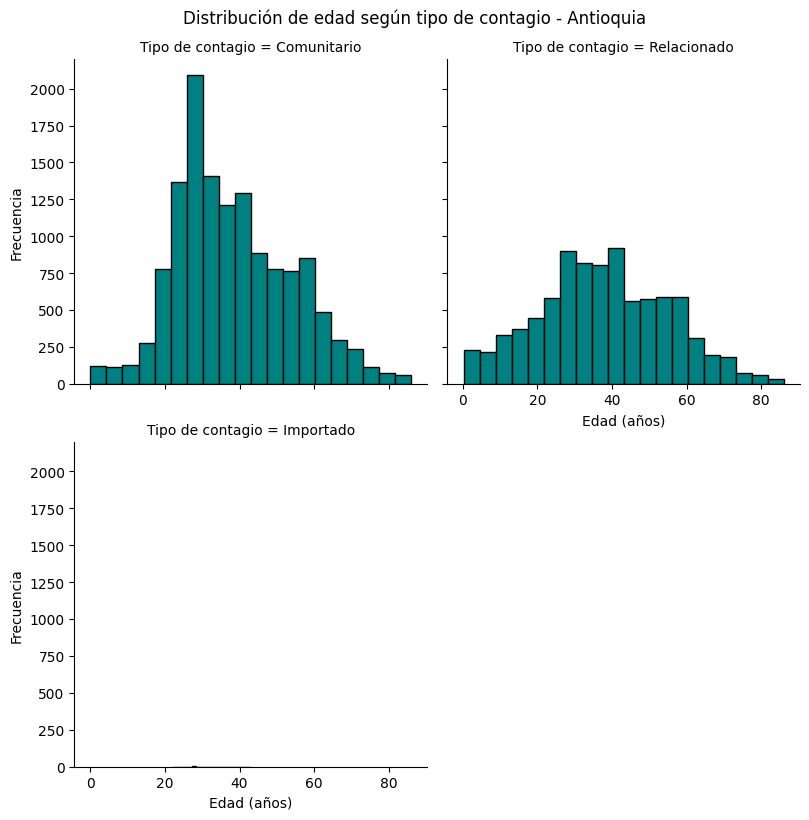

In [251]:
g = sns.FacetGrid(df_pairplot, col='Tipo de contagio', col_wrap=2, height=4)
g.map(plt.hist, 'Edad_anios', bins=20, color='teal', edgecolor='black')
g.set_axis_labels('Edad (años)', 'Frecuencia')
g.fig.suptitle('Distribución de edad según tipo de contagio - Antioquia', y=1.02)
plt.show()


Analizamos entonces la distribucion en contagio comunitario y relacionado para Antioquia.

Vemos que esta distribucion cambia, pero se recoce un pico en los 40 años, teniendo una distrbucion normal en la de constagios relacionados.

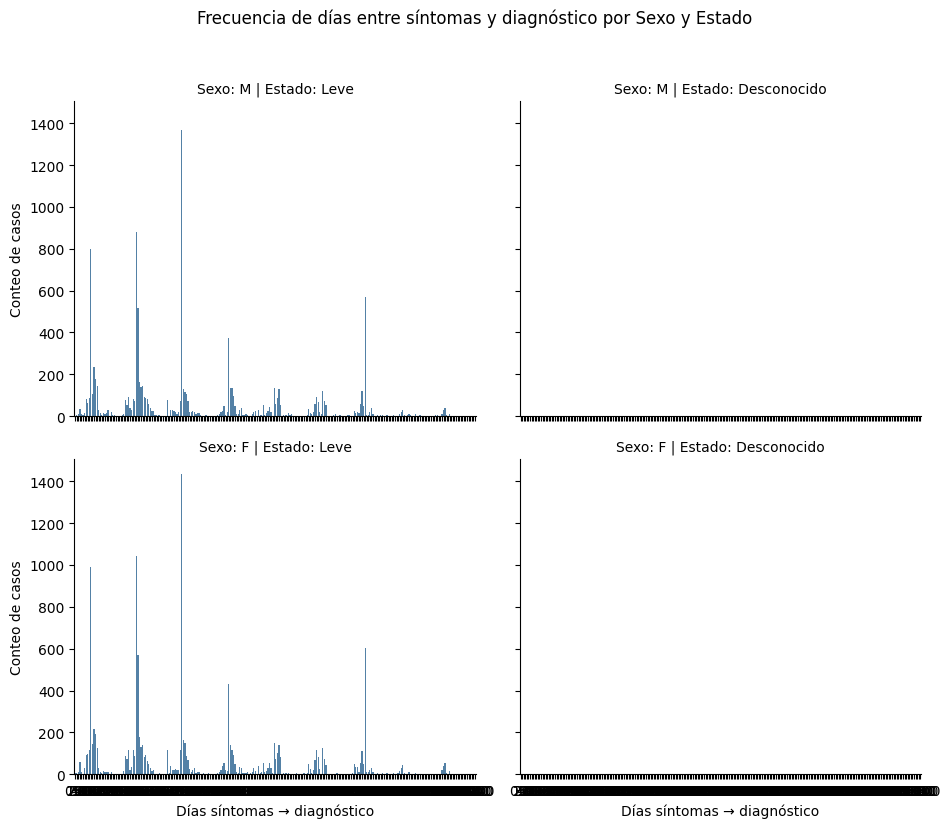

In [252]:
g = sns.FacetGrid(df_pairplot, row='Sexo', col='Estado', height=4, aspect=1.2)
g.map(sns.countplot, 'dias_sintomas_diagnostico', color='steelblue', order=sorted(df_pairplot['dias_sintomas_diagnostico'].unique()))
g.set_axis_labels('Días síntomas → diagnóstico', 'Conteo de casos')
g.set_titles(row_template='Sexo: {row_name}', col_template='Estado: {col_name}')
g.fig.suptitle('Frecuencia de días entre síntomas y diagnóstico por Sexo y Estado', y=1.03)
plt.tight_layout()
plt.show()

Las metricas con hombres y mujeres tienen una frecuencia similiar, relatando que no existe una diferencia significativa en el estado por sexo.

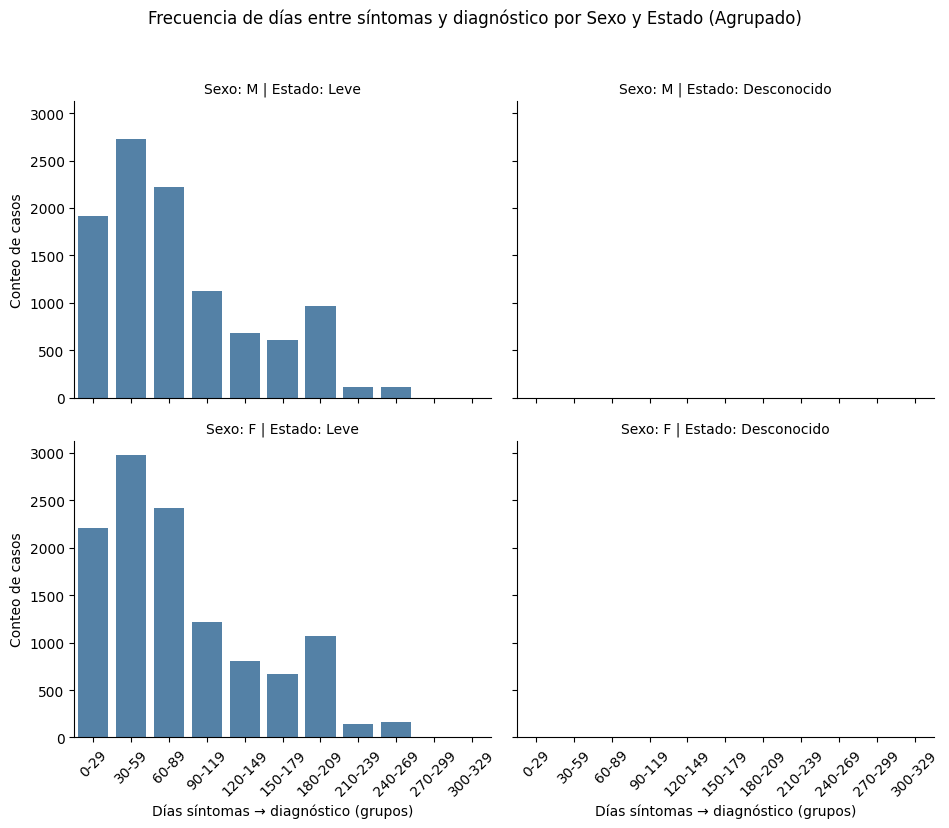

In [253]:
import matplotlib.pyplot as plt

# Definir rangos para mejor visualizacion- Carpinteria para mostrarla
bins_dias_sintomas = list(range(0, 331, 30)) # Hasta 330 para cubrir el max de 315
labels_dias_sintomas = [f'{i}-{i+29}' for i in bins_dias_sintomas[:-1]]

# Crear la nueva columna agrupada
df_pairplot['dias_sintomas_diagnostico_grouped'] = pd.cut(
    df_pairplot['dias_sintomas_diagnostico'],
    bins=bins_dias_sintomas,
    labels=labels_dias_sintomas,
    right=False,
    include_lowest=True
)

# Recrear el FacetGrid con la variable agrupada
g = sns.FacetGrid(df_pairplot, row='Sexo', col='Estado', height=4, aspect=1.2)
g.map(sns.countplot, 'dias_sintomas_diagnostico_grouped', color='steelblue', order=labels_dias_sintomas)
g.set_axis_labels('Días síntomas → diagnóstico (grupos)', 'Conteo de casos')
g.set_titles(row_template='Sexo: {row_name}', col_template='Estado: {col_name}')
g.fig.suptitle('Frecuencia de días entre síntomas y diagnóstico por Sexo y Estado (Agrupado)', y=1.03)

# Rotar las etiquetas del eje x para mejorar la legibilidad
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)

plt.tight_layout()
plt.show()

Distribución del tiempo de diagnóstico por Tipo de Contagio (agrupado) y Rango de Edad



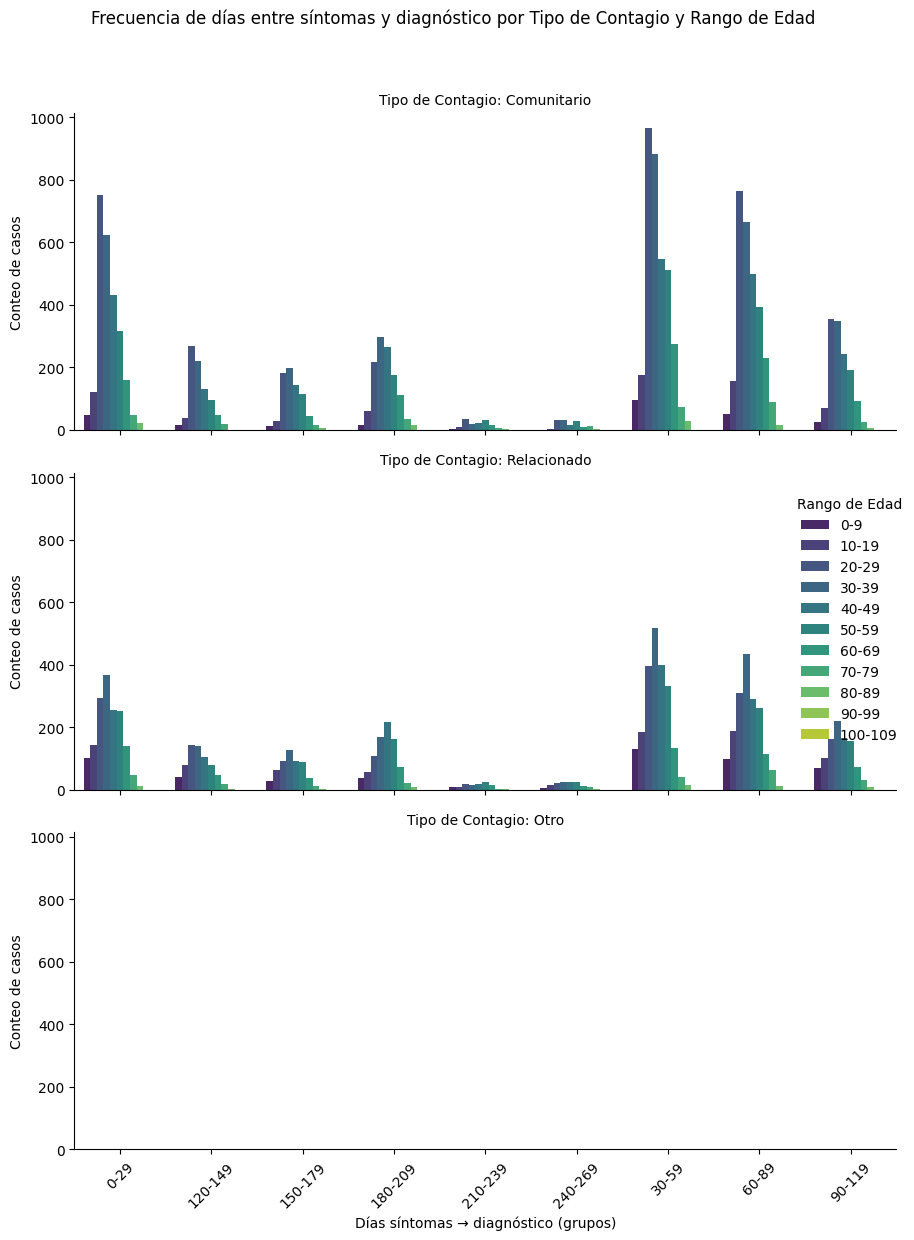

In [254]:
# Crear la columna 'Tipo_contagio_agrupado' en df_pairplot
df_pairplot['Tipo_contagio_agrupado'] = df_pairplot['Tipo de contagio'].replace({'Importado': 'Otro', 'Desconocido': 'Otro'})

# Obtener el orden de las etiquetas para el eje x (dias_sintomas_diagnostico_grouped)
order_dias_sintomas_grouped = sorted(df_pairplot['dias_sintomas_diagnostico_grouped'].dropna().unique())

# Crear el FacetGrid
g = sns.FacetGrid(df_pairplot, row='Tipo_contagio_agrupado', height=4, aspect=2)
g.map_dataframe(sns.countplot, 'dias_sintomas_diagnostico_grouped', hue='Rango_edad', palette='viridis', order=order_dias_sintomas_grouped)
g.set_axis_labels('Días síntomas → diagnóstico (grupos)', 'Conteo de casos')
g.set_titles(row_template='Tipo de Contagio: {row_name}')
g.add_legend(title='Rango de Edad')
g.fig.suptitle('Frecuencia de días entre síntomas y diagnóstico por Tipo de Contagio y Rango de Edad', y=1.03)

# Rotar las etiquetas del eje x para mejorar la legibilidad
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)

plt.tight_layout()
plt.show()

En la grafica podemos ver la prevalencia de casos en cada tipo de contagio, con su conteo relacitvo y los dias de sintomas. Podemos concluir que en la mayoria de casos relacionados, se reportaron sintomas en los primeros dias, sin embargo vemos una ola, entre los doas 30-60 donde predominan las edades de 20-60. El tipo de contagio "otro" tiene pocos casos y la mayoria reportan sintomas de 0-29 dias o en los dias 30 o 60, pero el recuento es mucho menor a los mencionados anteriormente.